In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os
from scipy.stats import chi2_contingency
from datetime import timedelta

from etl.customer import aggregate_customer
from etl.subsidy import report_customer_conversion_by_subsidy_issue_status, report_customer_metrics_by_subsidy_issue_status
from etl.subsidy import visualize_conversion_by_subsidy_issues, report_customer_subsidy_issues_by_product
from etl.subsidy import visualize_customer_subsidy_issues_by_product, visualize_policy_suspension_impact
from etl.price import visualize_conversion_by_price_sweet_spots, visualize_conversion_by_price_sweet_spots_variant
from etl.price import report_product_conversion_by_price_quartile, visualize_conversion_by_equipment_category_price
from etl.price import visualise_conversion_by_brand_price, show_two_panel_conversion_by_brand_price
from etl.price import visualize_conversion_by_equipment_type_brand_price, show_conversion_by_price_dashboard, show_product_type_price_conversion_heatmap
from etl.season import visualize_conversion_by_season, visualize_regional_seasonality
from etl.period import visualize_conversion_by_year, report_best_and_worst_months, show_conversion_by_price_over_time, overlay_all_years_on_one_plot
from etl.period import visualize_conversion_by_prices_sweet_spot_shift, visualize_decision_times, show_decision_time_dashboard
from etl.product import visualise_heat_pump_performance, show_product_type_by_brand_heatmap, show_product_type_by_agency_heatmap, show_brand_by_product_type_heatmap


import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

Loaded data: 37,008 quotes from 25,716 customers


In [2]:
customers = aggregate_customer(df_clean)

Quote-level columns created:
  - out_of_pocket: 34,991 values
  - subsidy_issue: 9,076 issues (24.5%)
  - brand-product pairs: 146 unique combinations

BRAND-PRODUCT VALIDATION

❌ ATLANTIC + Stove customers (should be 0): 0
✅ FIXED: No ATLANTIC + Stove combinations found!

✅ Customer dataset created: 25,716 customers
✅ Total columns: 61
✅ Key columns now available:
   - main_brand: from brand-product pair (most common option)
   - main_equipment_category: from brand-product pair (most common option)
   - brand_product_nunique: 1.2 avg options per customer
   - shopped_around: 4,484 customers (17.4%)
   - decision_days: from customer_duration_days
   - price_cv: from std_out_of_pocket / avg_out_of_pocket
   - quote_count: alias for total_quotes
   - price_range: 1142 avg
   - price_volatility: 0.26 avg

Subsidy issue type distribution:
subsidy_issue_type
No Issues            18660
Both                  2480
CEE Only              2361
MaPrimeRénov Only     2215
Name: count, dtype: int64


In [3]:
all_customers = pd.read_csv('customer_master_data.csv')

In [4]:
# Using quarter column (if you have it)
customers_2026_q1 = all_customers[
    (all_customers['year'] == 2026) & 
    (all_customers['quarter'] == 1)
]

# Using date range
customers_2026_q1 = all_customers[
    (all_customers['first_quote_date'] >= '2026-01-01') & 
    (all_customers['first_quote_date'] <= '2026-03-31')
]

print(f"Q1 2026 customers: {len(customers_2026_q1):,}")

Q1 2026 customers: 2,397


In [5]:
customers = customers_2026_q1


Customer conversion by subsidy issue status:

                   conversion_rate  customer_count  converted_count
had_subsidy_issue                                                  
False                     0.256855            1787            459.0
True                      0.285246             610            174.0

Chi-square p-value: 1.867727e-01
Statistically significant: NO

Conversion without issues: 25.69%
Conversion with issues: 28.52%
Difference: 2.8 percentage points
Customer-level finding: +2.8 points

Customer characteristics by subsidy issue status

Metric comparison:

total_quotes:
  No issues: 1.36
  With issues: 1.47
  Ratio: 1.09x

avg_quote_amount:
  No issues: 5717.54
  With issues: 9724.94
  Ratio: 1.70x

max_quote_amount:
  No issues: 6037.00
  With issues: 10637.81
  Ratio: 1.76x

customer_duration_days:
  No issues: 2.15
  With issues: 3.01
  Ratio: 1.40x

price_range:
  No issues: 698.12
  With issues: 1805.23
  Ratio: 2.59x

multiple_quotes:
  No issues: 0.27


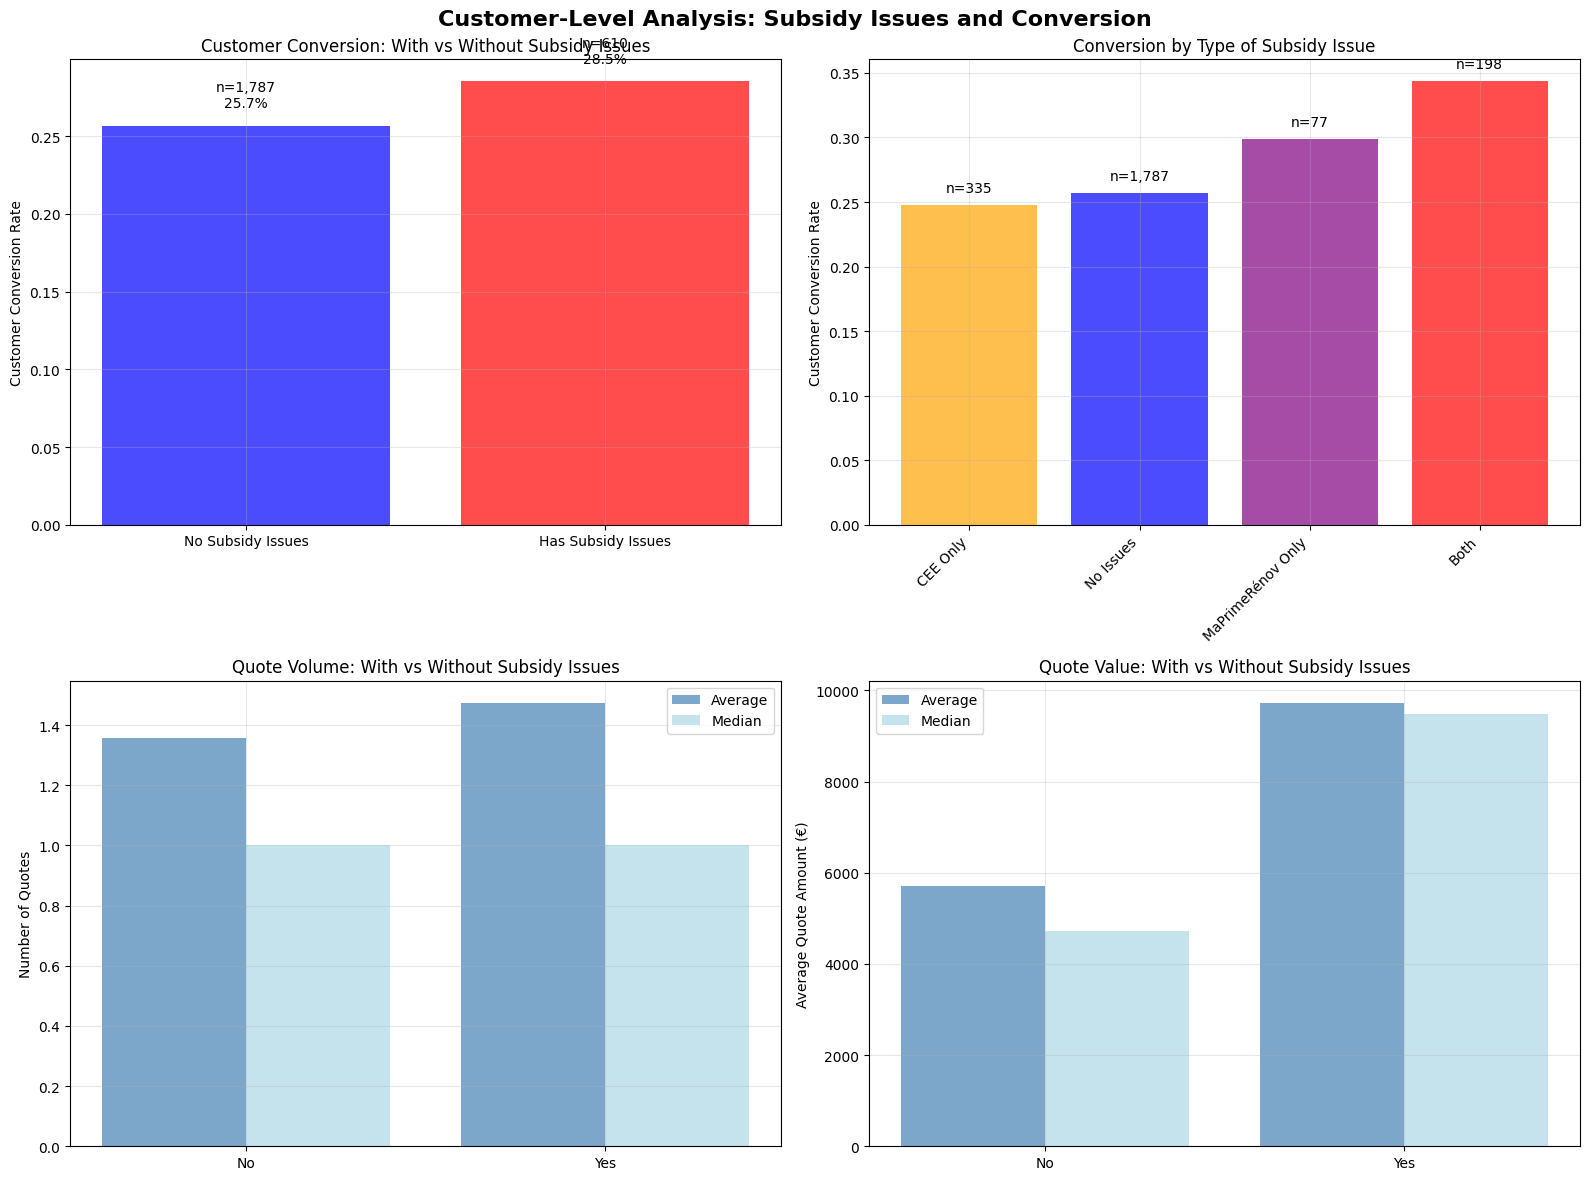


Policy Suspension Impact

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126
Unique values in during_suspension: [False  True]

Conversion during subsidy suspensions:
                       mean  count
Normal Periods     0.244562   1701
During Suspension  0.323481    609

Suspension impact p-value: 0.0002
Statistically significant: YES

Product mix during suspensions:
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove
during_suspension                                             
False                    22.1    31.1       16.6    8.9   21.3
True                     13.5    38.6       14.8    8.4   24.8


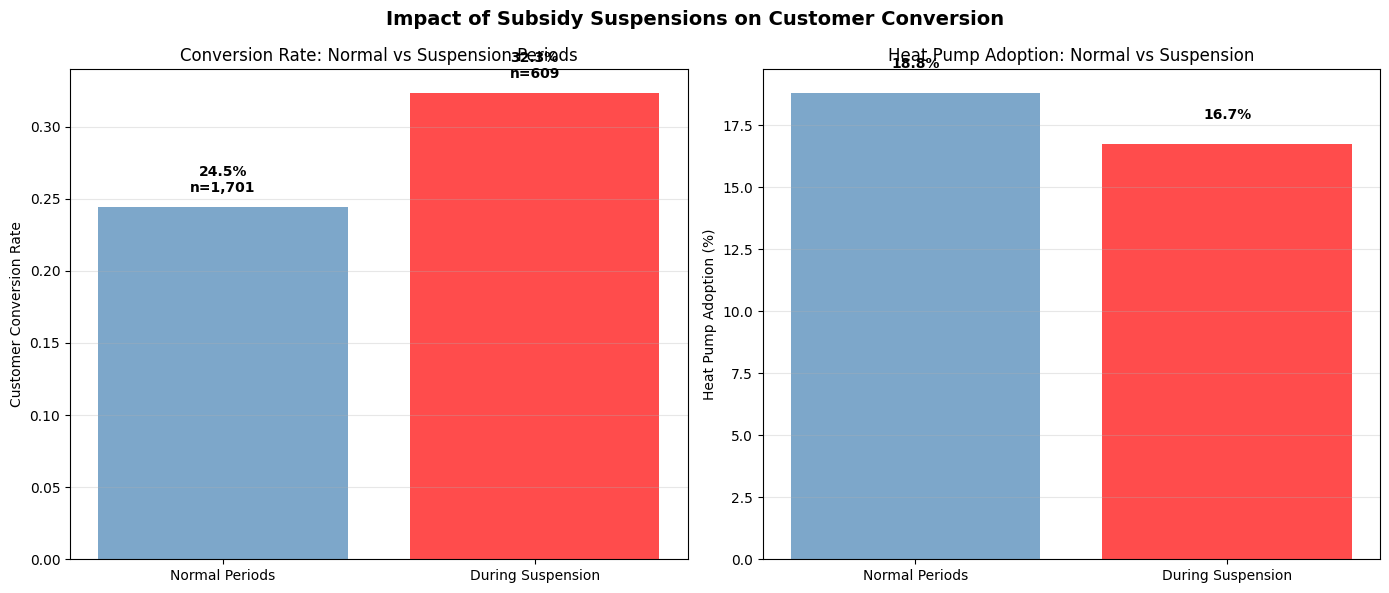

Unique values in main_product_family:
main_product_family
Chaudière                           797
Poêle                               518
Climatisation                       472
Pompe à chaleur                     373
ECS : Chauffe-eau ou adoucisseur    139
Photovoltaïque                       36
Unknown                              16
Autres                               16
Emetteur de chauffage  ou chappe     14
Produit VMC                           8
Appareil hybride                      3
Accessoire de pose                    3
Plomberie Sanitaire                   2
Name: count, dtype: int64

Top products:
main_product_family
Chaudière                           797
Poêle                               518
Climatisation                       472
Pompe à chaleur                     373
ECS : Chauffe-eau ou adoucisseur    139
Photovoltaïque                       36
Unknown                              16
Autres                               16
Emetteur de chauffage  ou chappe     14
P

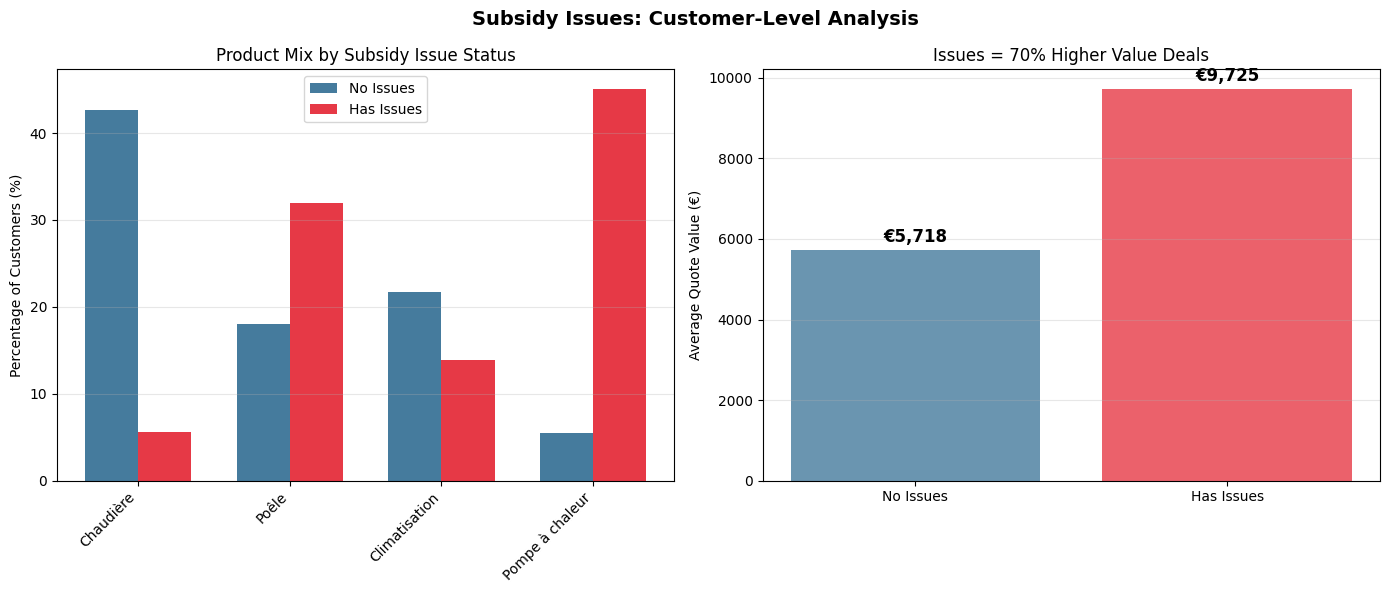


Threshold effect

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126


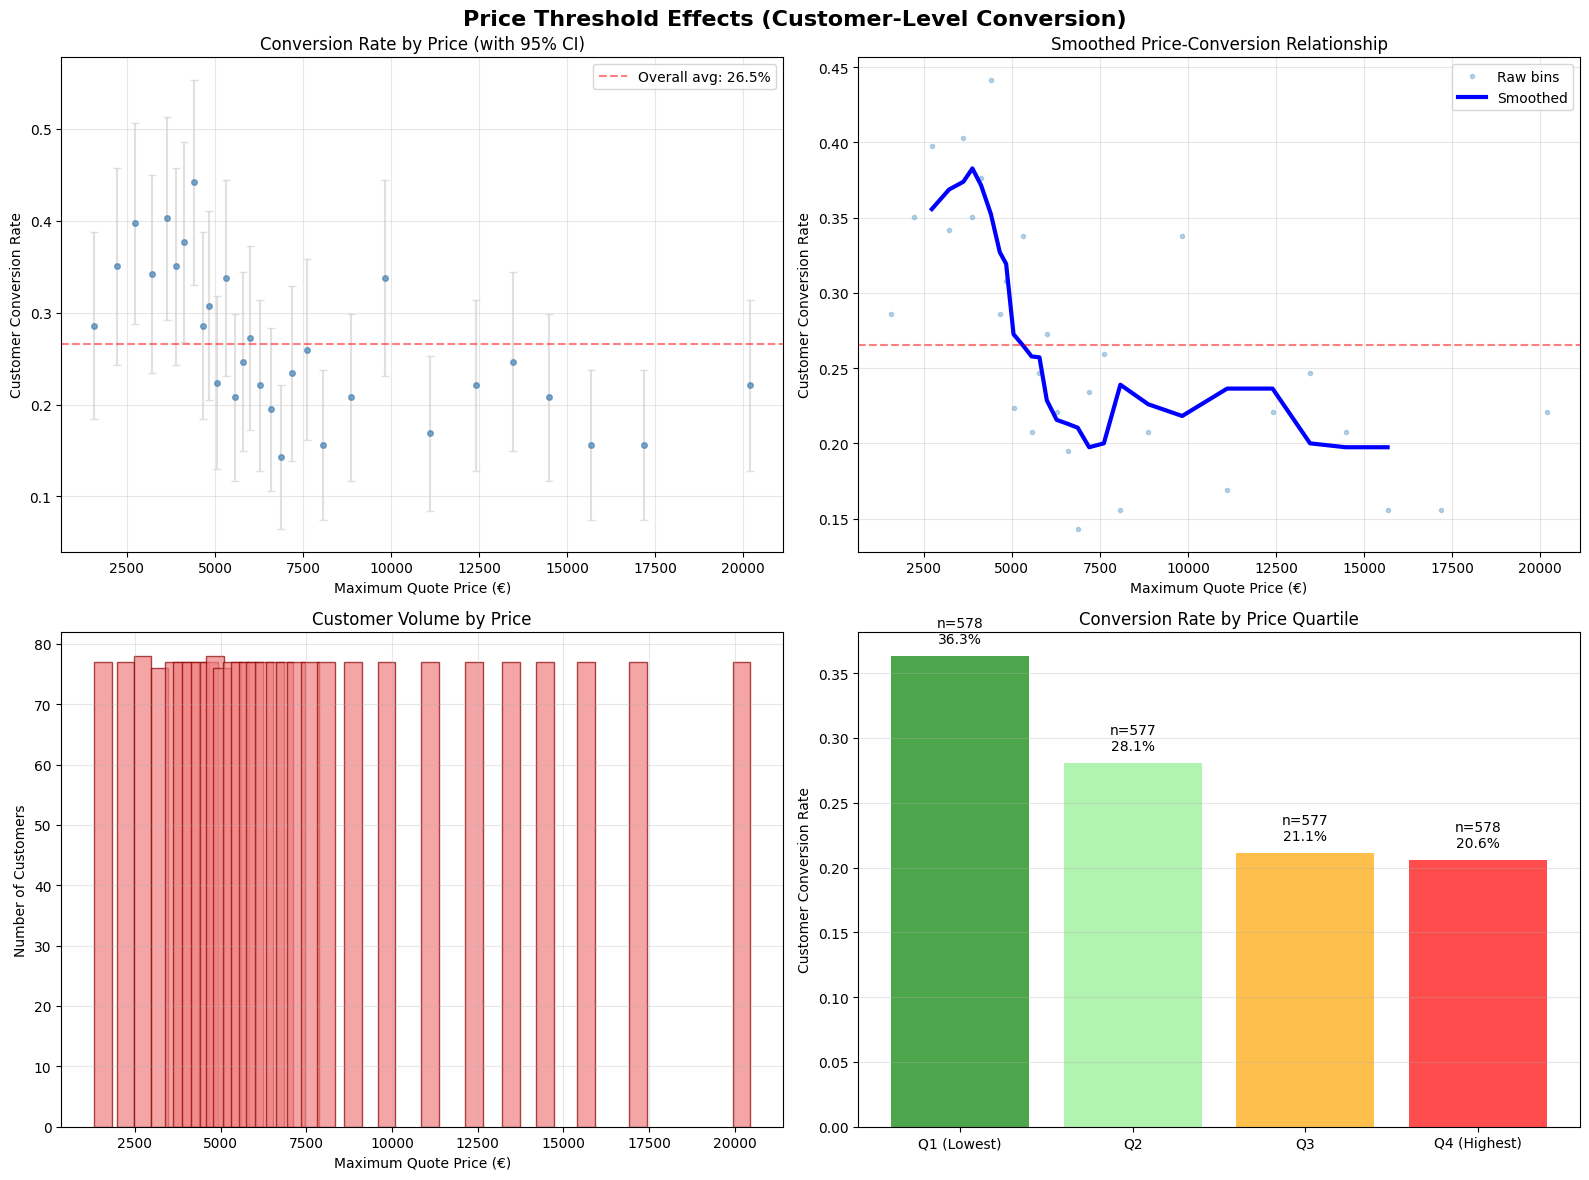


THRESHOLD EFFECT: KEY FINDINGS

Conversion by Price Quartile:
  Q1 (Lowest): 36.3% (n=578)
  Q2: 28.1% (n=577)
  Q3: 21.1% (n=577)
  Q4 (Highest): 20.6% (n=578)

Difference between lowest and highest quartile: 15.7 percentage points

Sweet spots (above-average conversion):
  €1,567: 28.6% (n=77)
  €2,224: 35.1% (n=77)
  €2,728: 39.7% (n=78)
  €3,217: 34.2% (n=76)
  €3,624: 40.3% (n=77)
  €3,880: 35.1% (n=77)
  €4,128: 37.7% (n=77)
  €4,404: 44.2% (n=77)
  €4,658: 28.6% (n=77)
  €4,838: 30.8% (n=78)
  €5,327: 33.8% (n=77)
  €5,993: 27.3% (n=77)
  €9,838: 33.8% (n=77)

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126

Product mix by price quartile

Product distribution by price quartile (%):
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove
price_quartile                                                
Q1_Low                   20.2    46.9        0.0   27.1    5.8
Q2_MidLow                15.4    44.0        0.2    2.9   37.5
Q3_MidHigh         

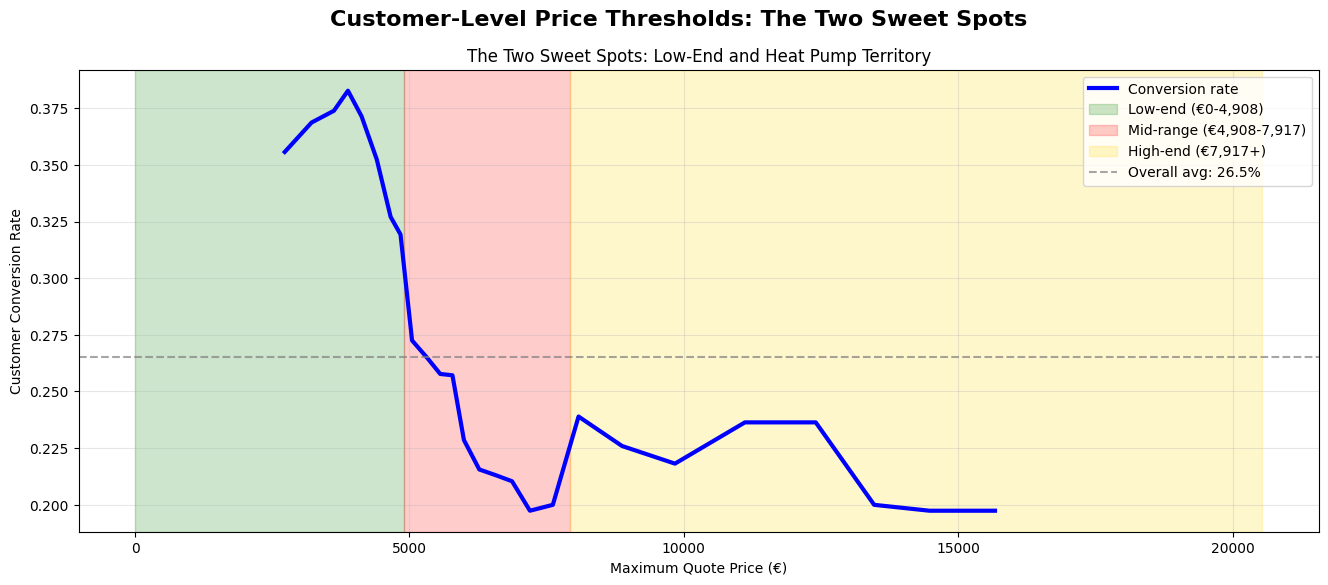

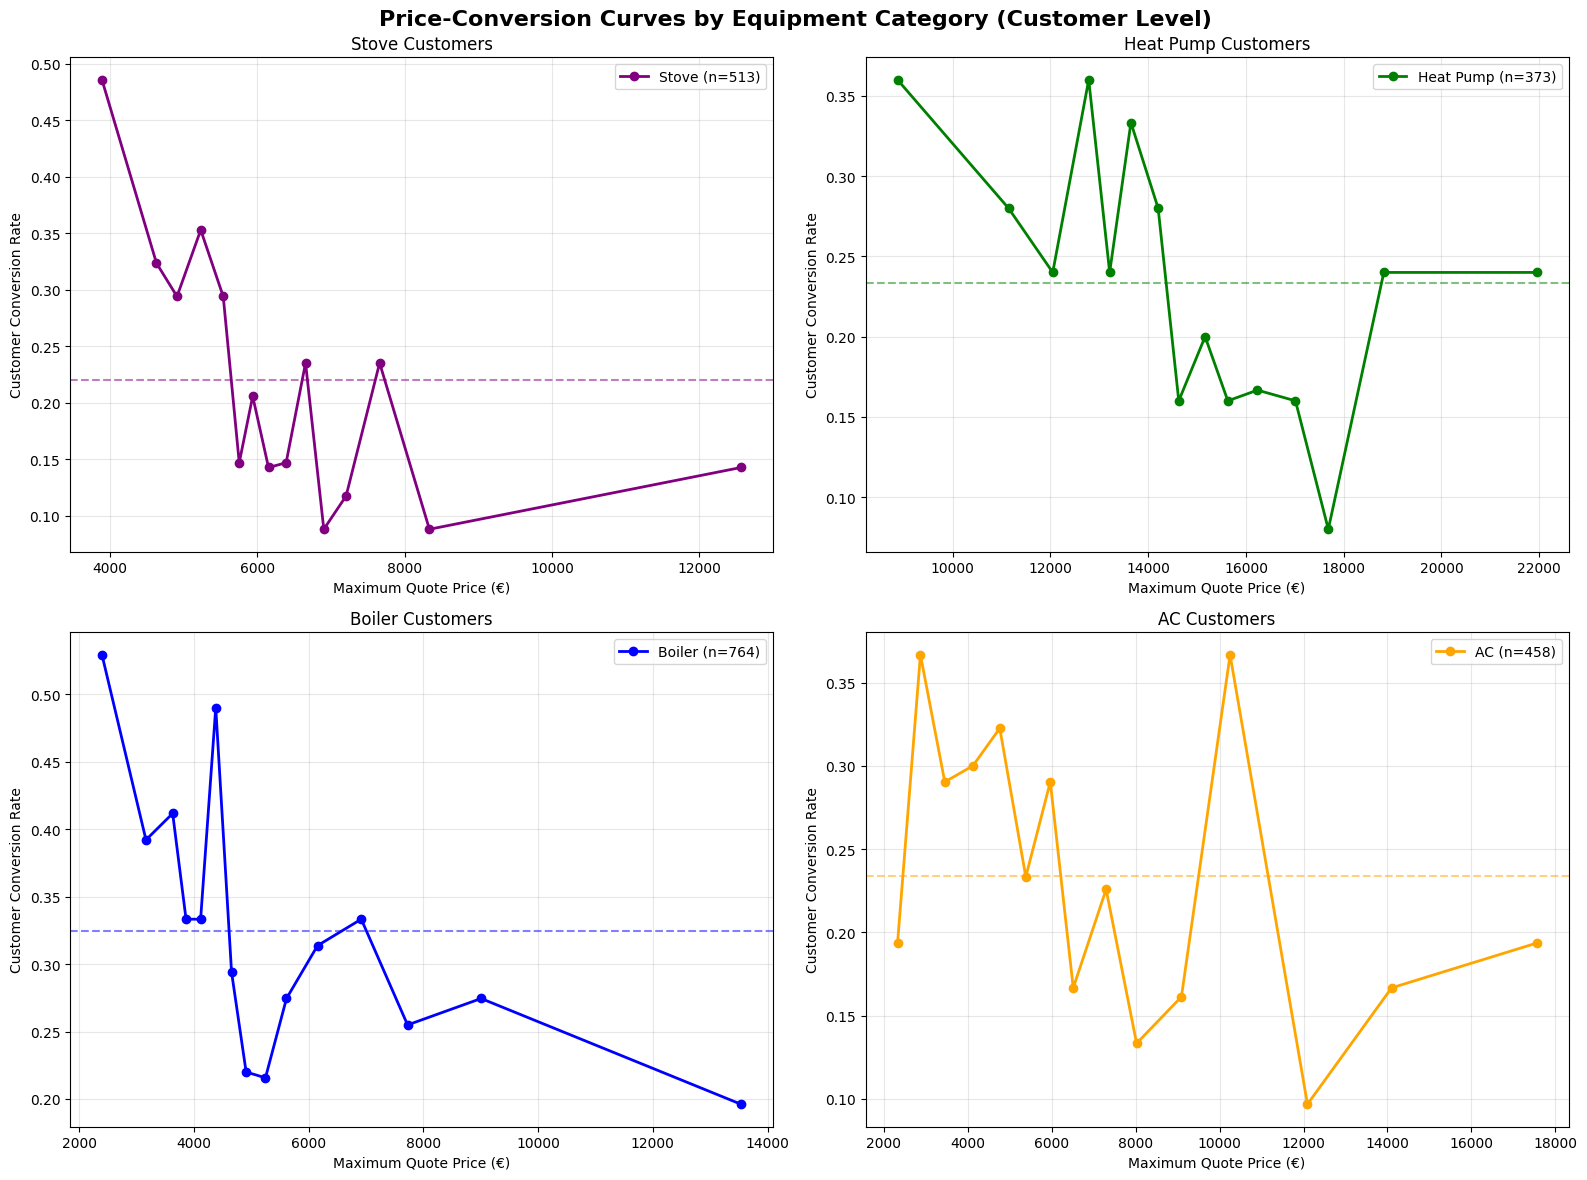


Conversion by Brand Price

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126
Top 8 brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'MCZ', 'SAUNIER DUVAL', 'E.L.M. LEBLANC', 'DE DIETRICH', 'FRISQUET', 'ORANIER']


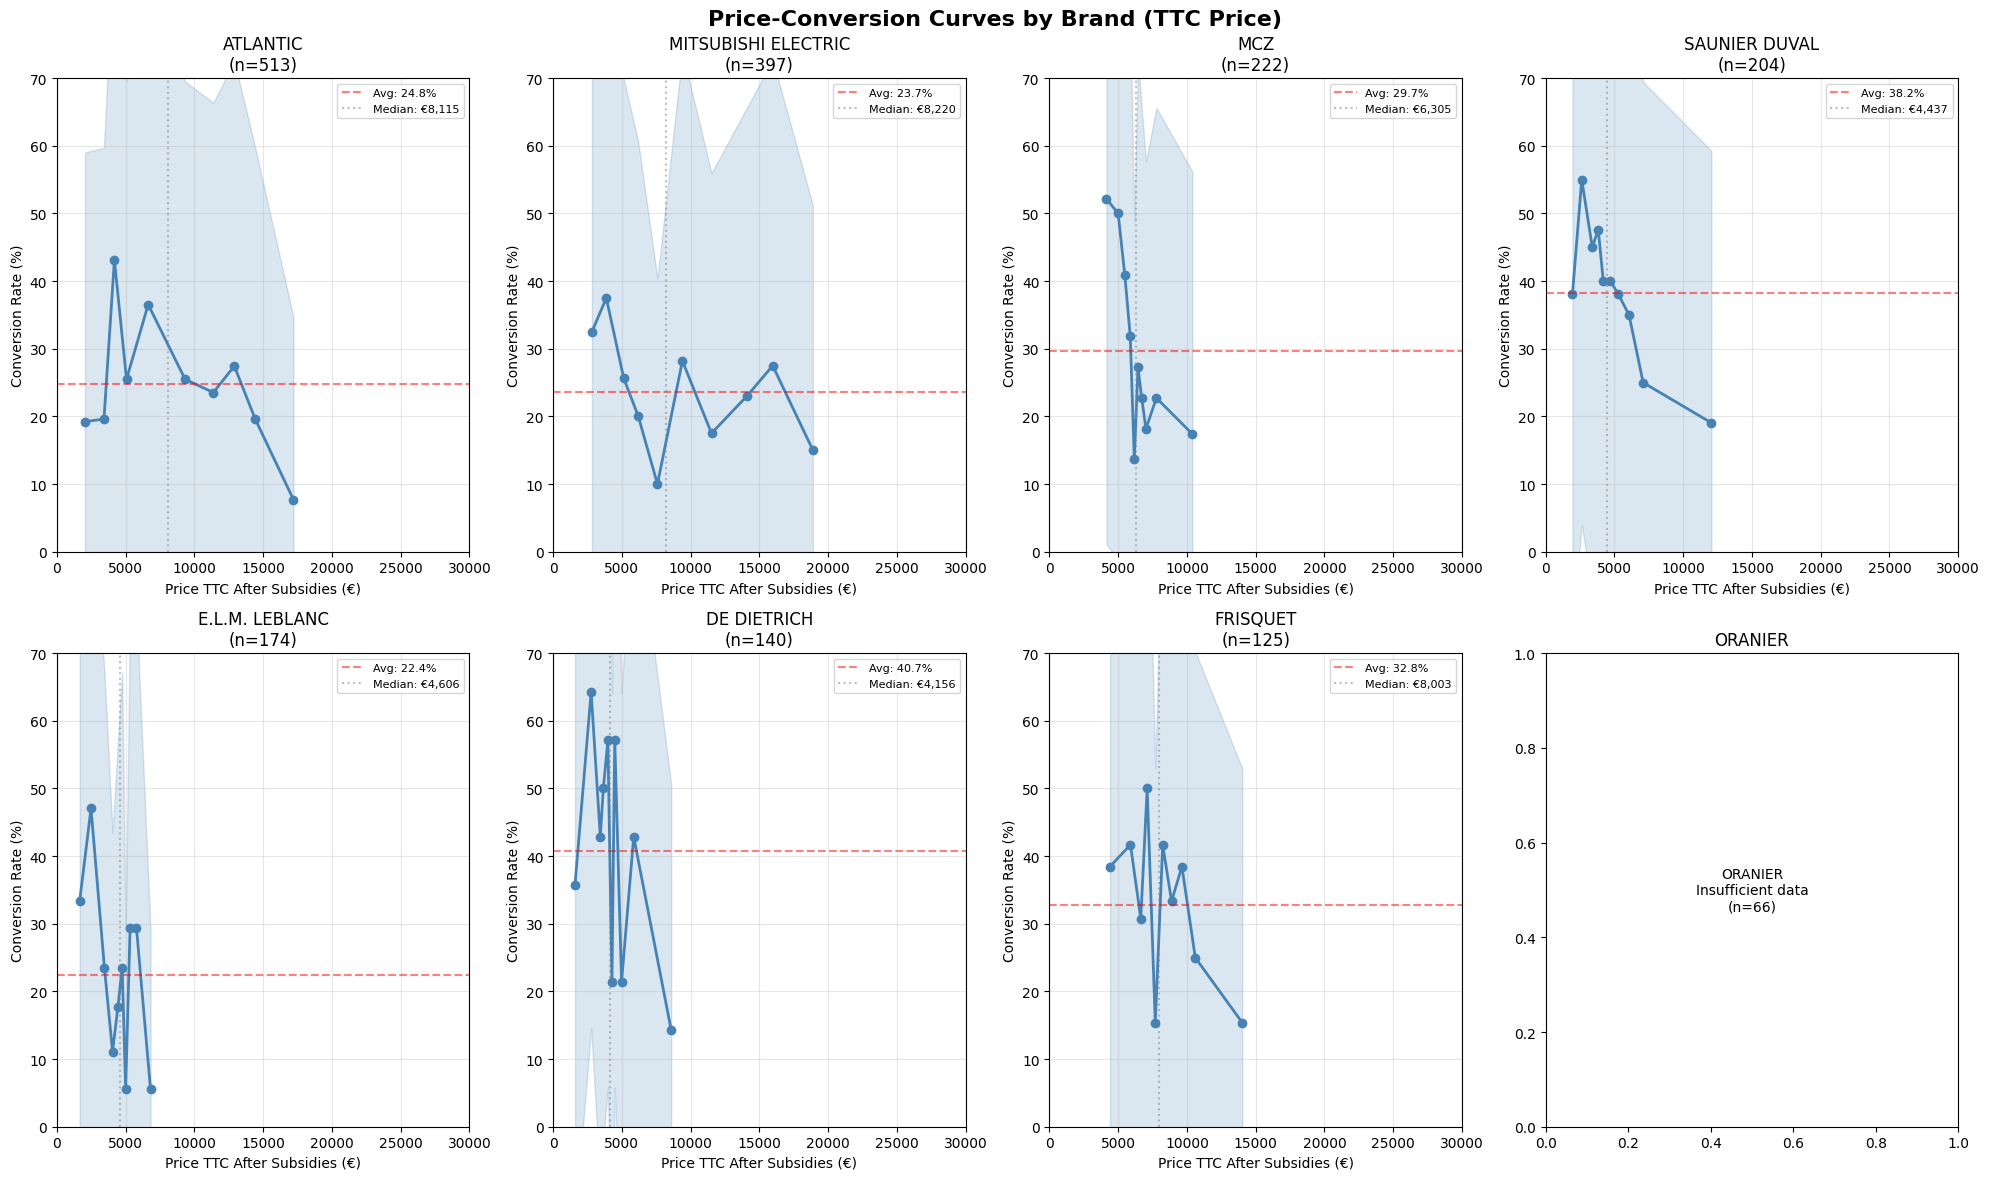


Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126


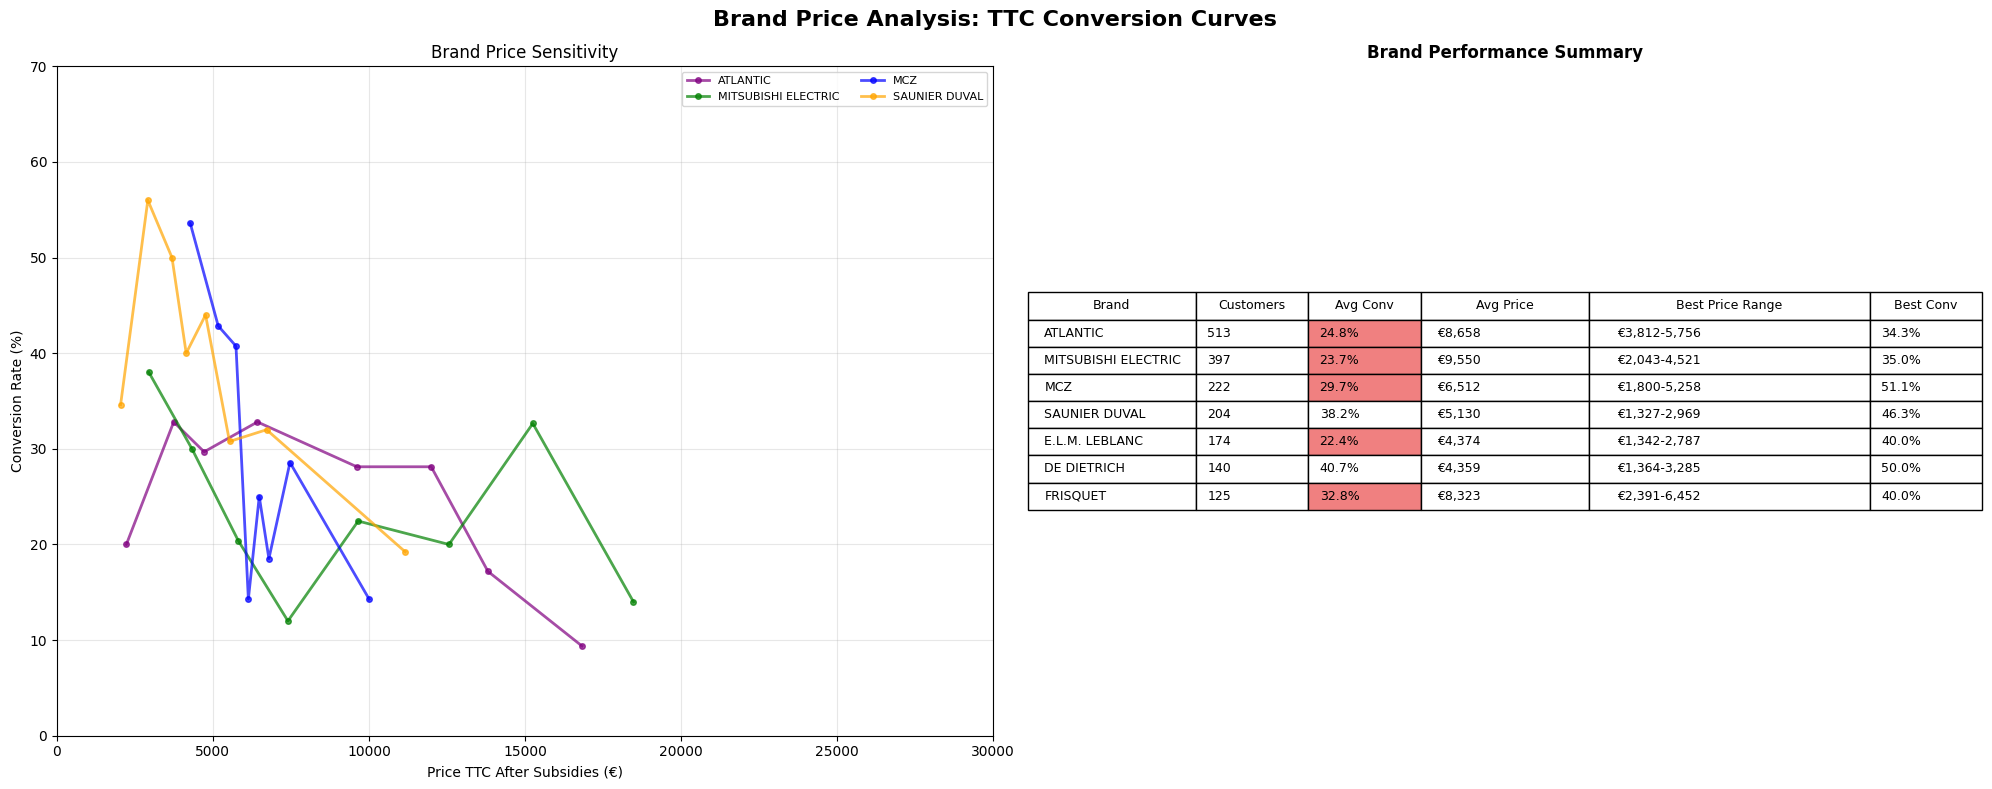


TTC Price-conversion curves: 4 equipment types, multiple brands per graph

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126

Heat Pump - Top brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC']

Boiler - Top brands: ['SAUNIER DUVAL', 'E.L.M. LEBLANC', 'DE DIETRICH', 'FRISQUET', 'ATLANTIC']

Stove - Top brands: ['MCZ', 'ORANIER', 'PALAZZETTI']

AC - Top brands: ['MITSUBISHI ELECTRIC', 'ATLANTIC']


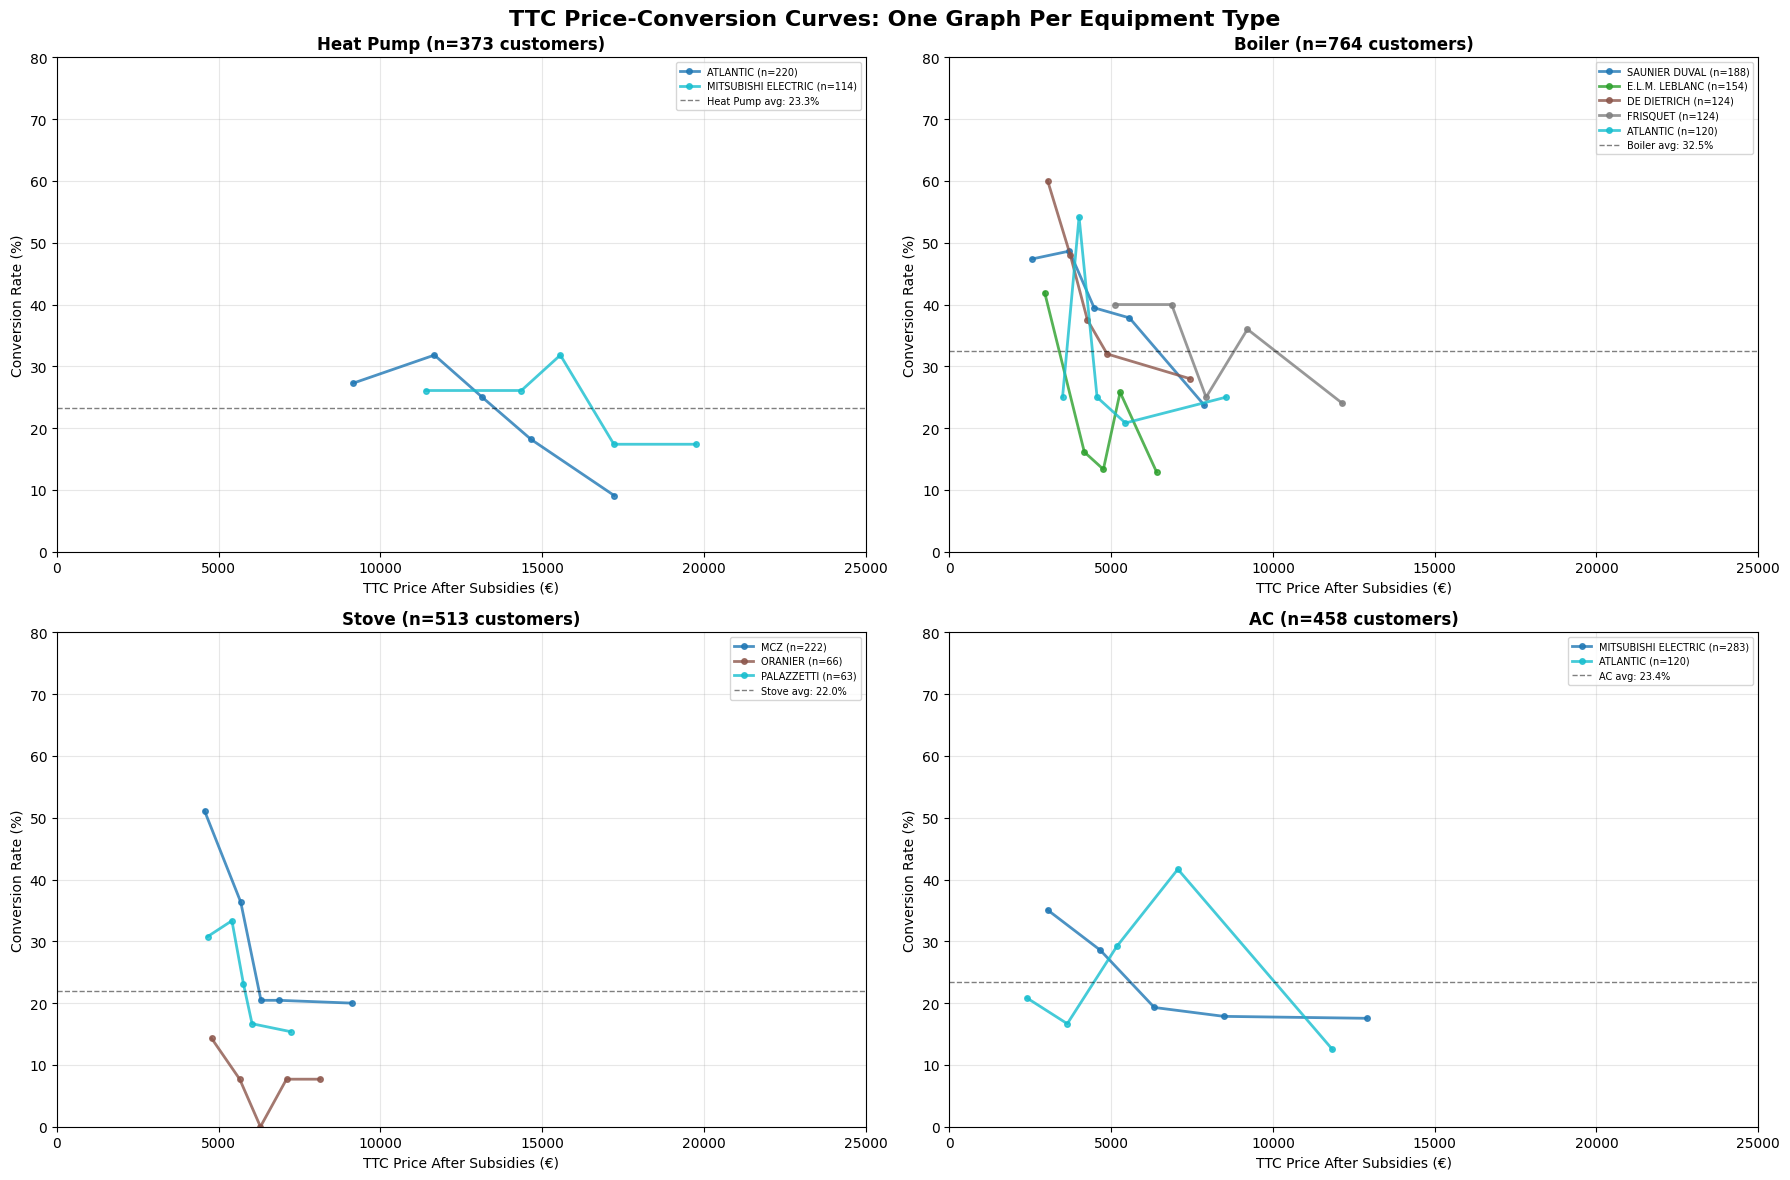


Seasonal Effects on Customer Conversion


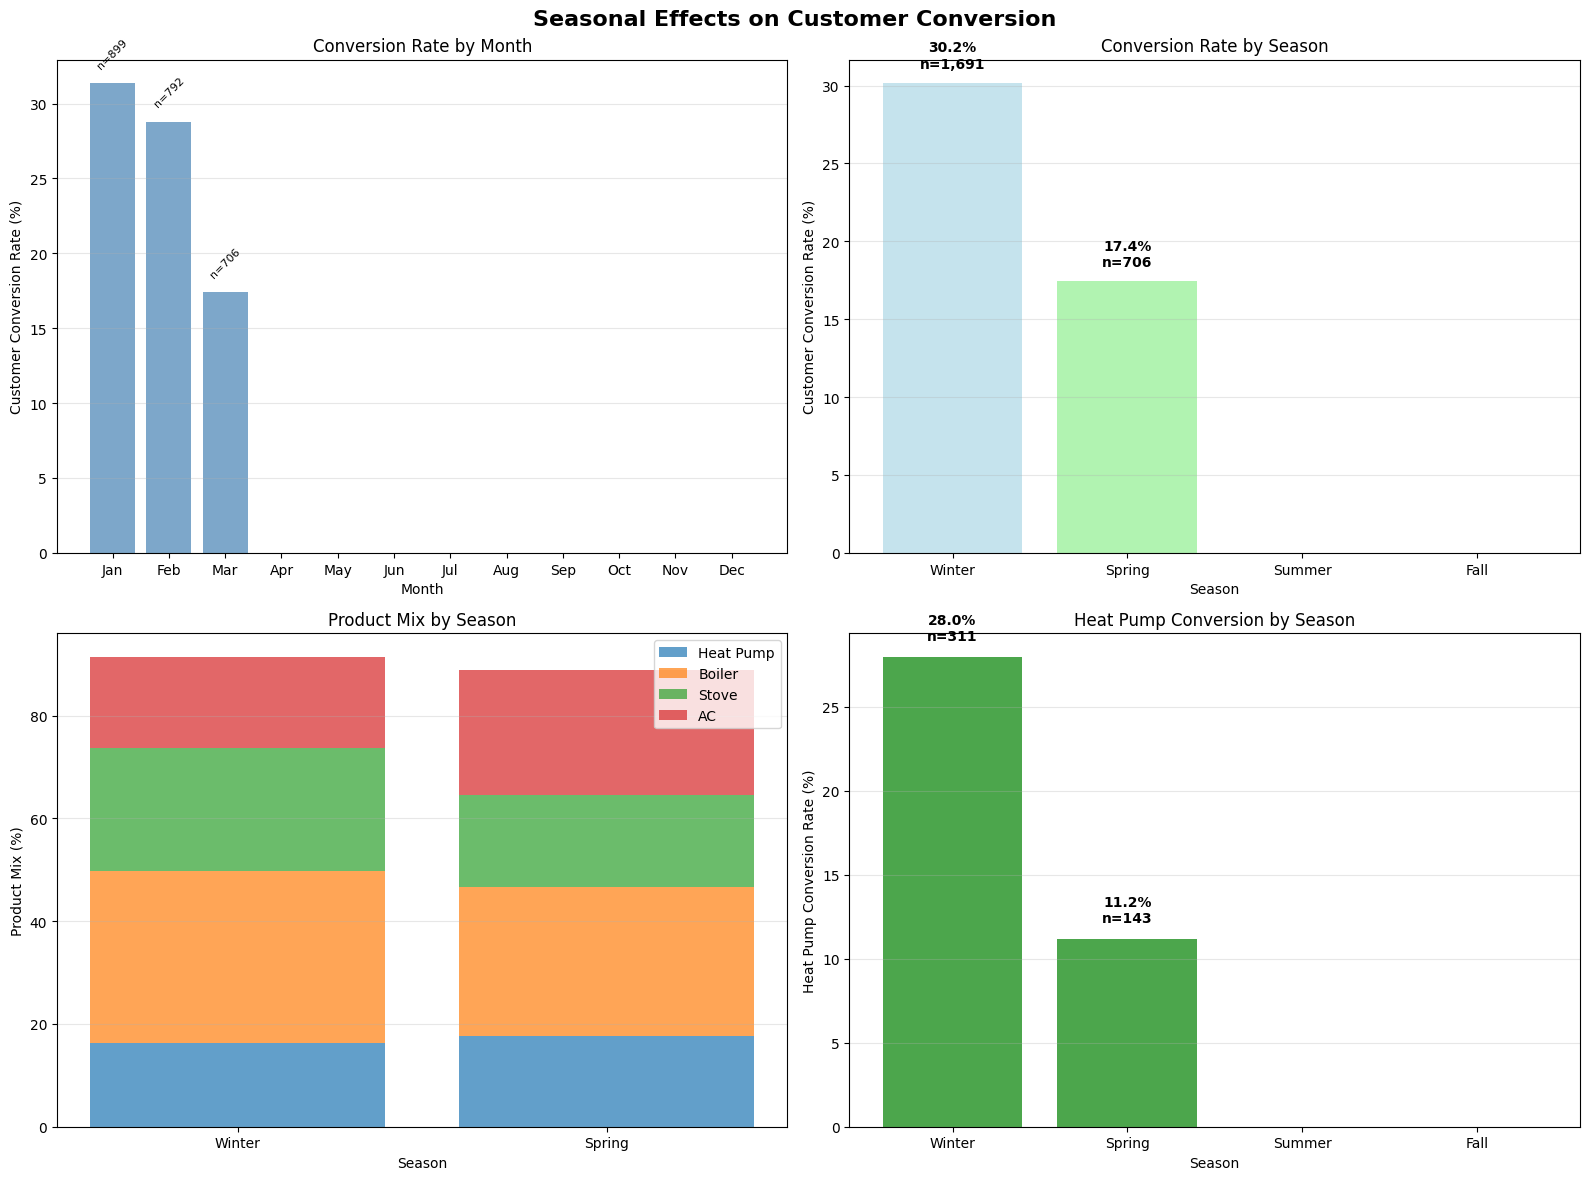


SEASONAL STATISTICS

Conversion by season:
  Winter: 30.2% (n=1,691)
  Spring: 17.4% (n=706)

Seasonality chi-square p-value: 0.0000
Statistically significant: YES

Regional Seasonal Pattern

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126

Top regions: ['Auvergne-Rhône-Alpes', 'Normandie', 'Hauts-de-France']


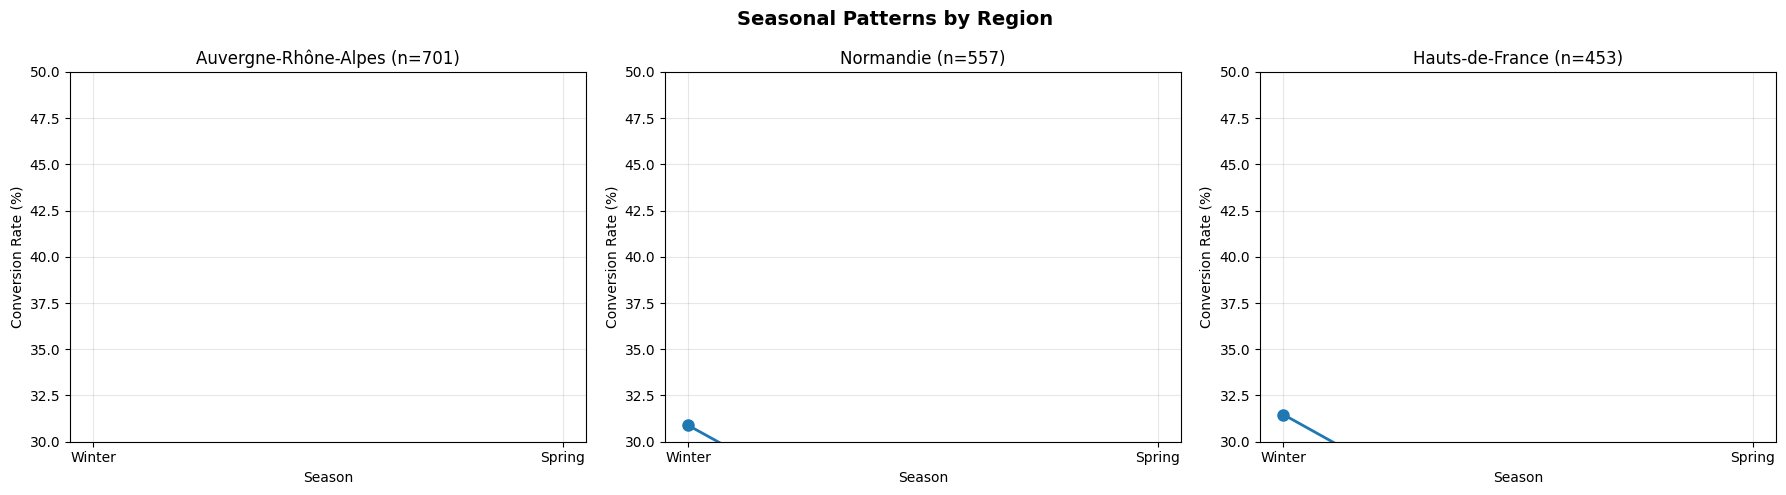


Year-over-year trends

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126

Quarterly conversion rates:
                  mean  count
year_quarter                 
2026Q1        0.265368   2310


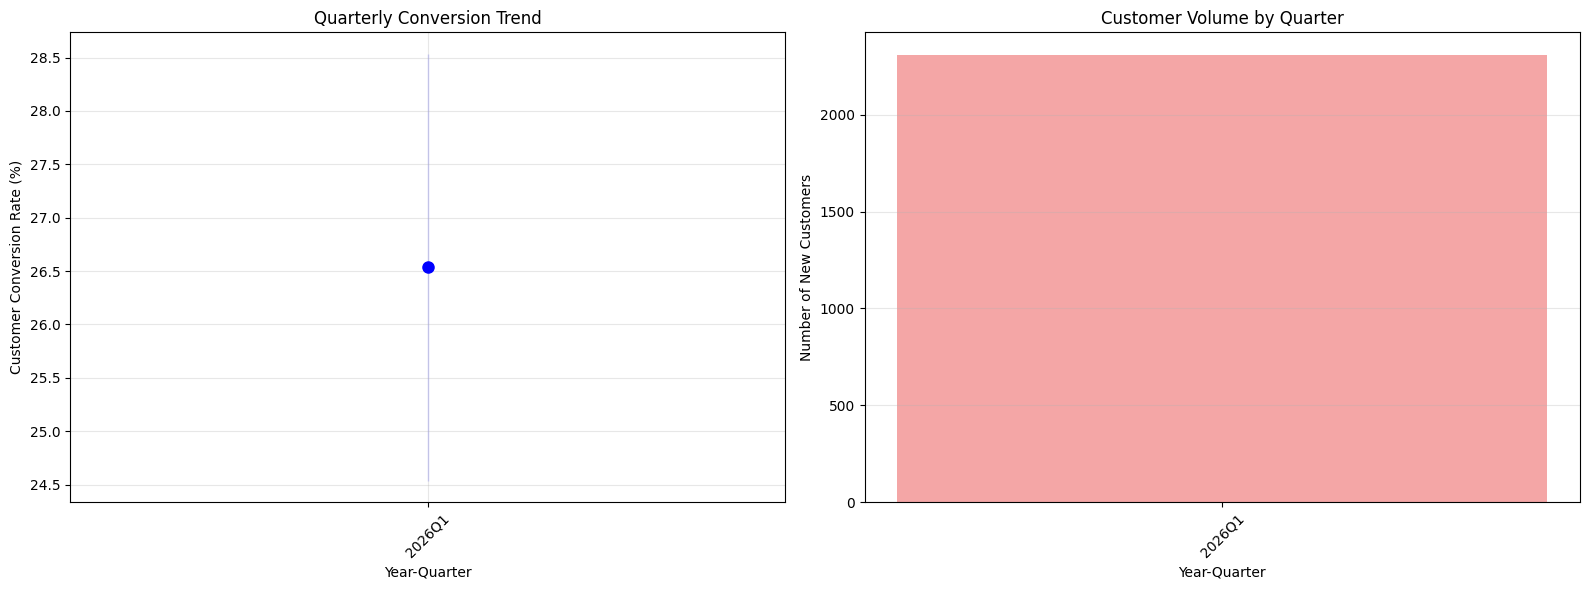


Best and Worst Months Report

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126

Conversion during subsidy suspensions:
                       mean  count
Normal Periods     0.244562   1701
During Suspension  0.323481    609

Suspension impact p-value: 0.0002
Statistically significant: YES

Best month: 1 (31.7%, n=871)

Best season: Winter (30.2%)
Worst season: Spring (17.8%)

Heat pump conversion by season:
  Winter: 29.1%
  Spring: 12.0%

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126


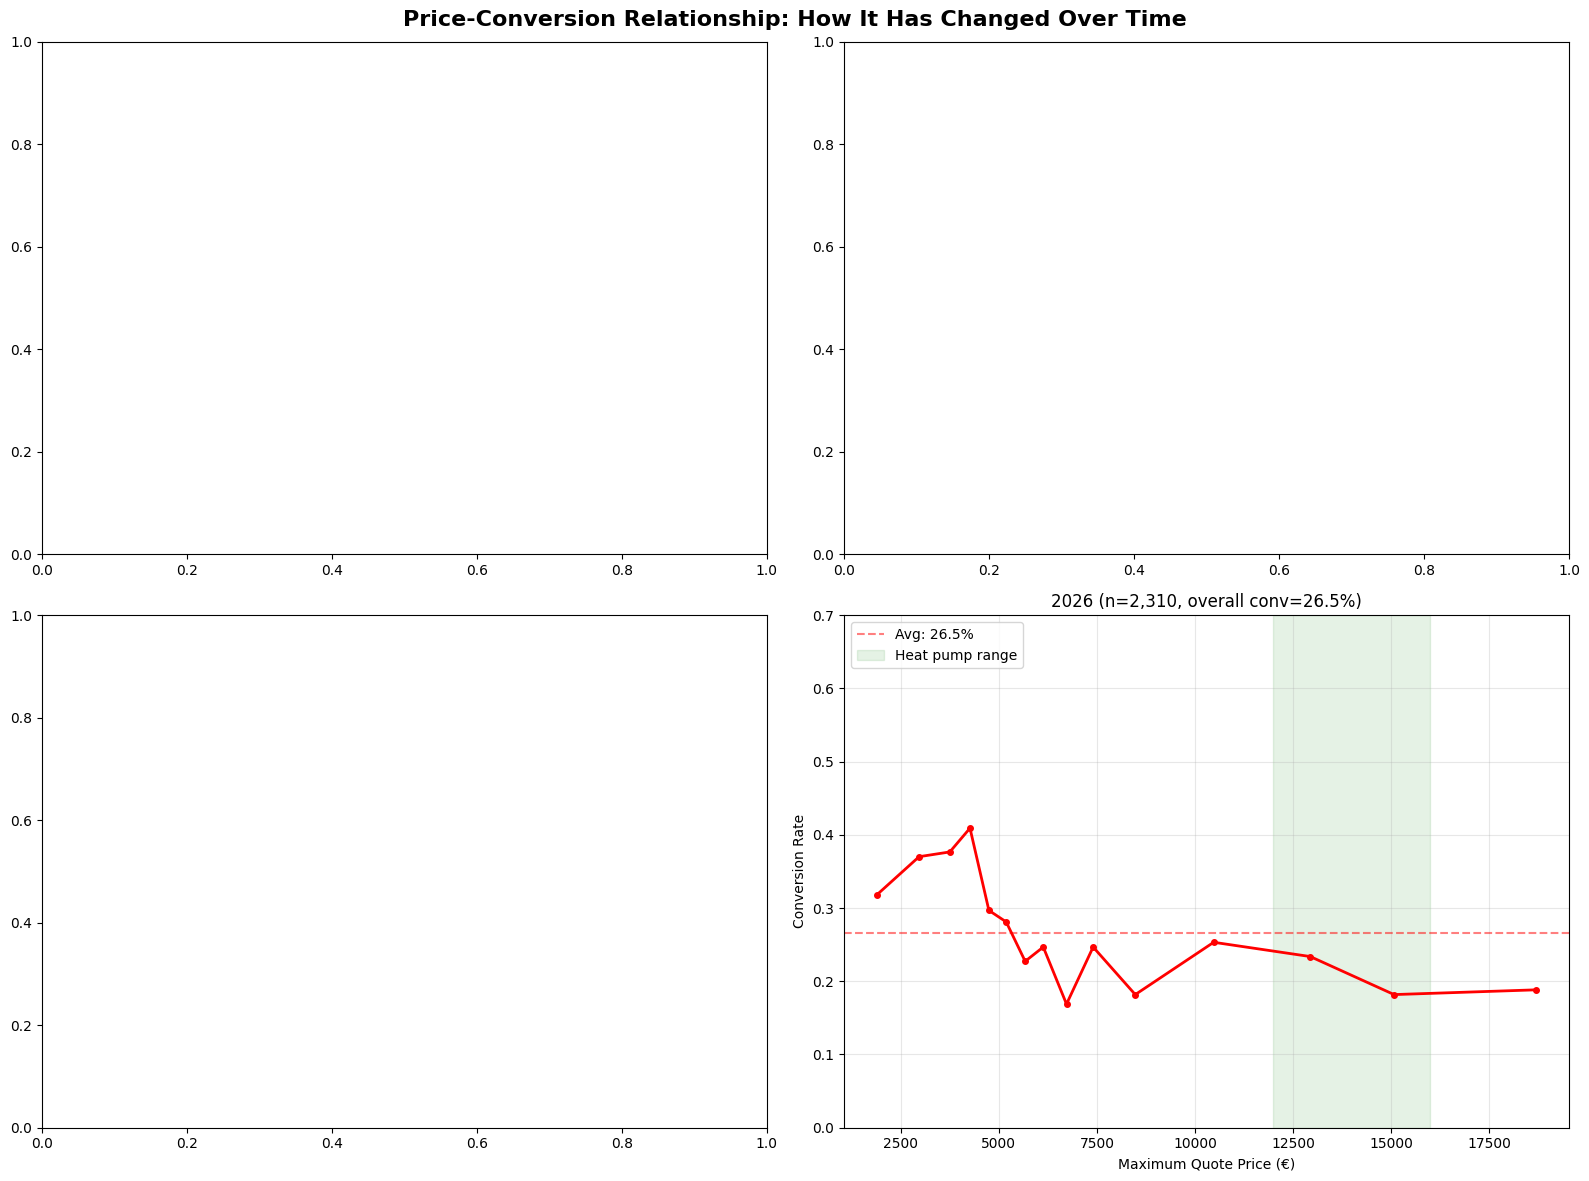


Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126


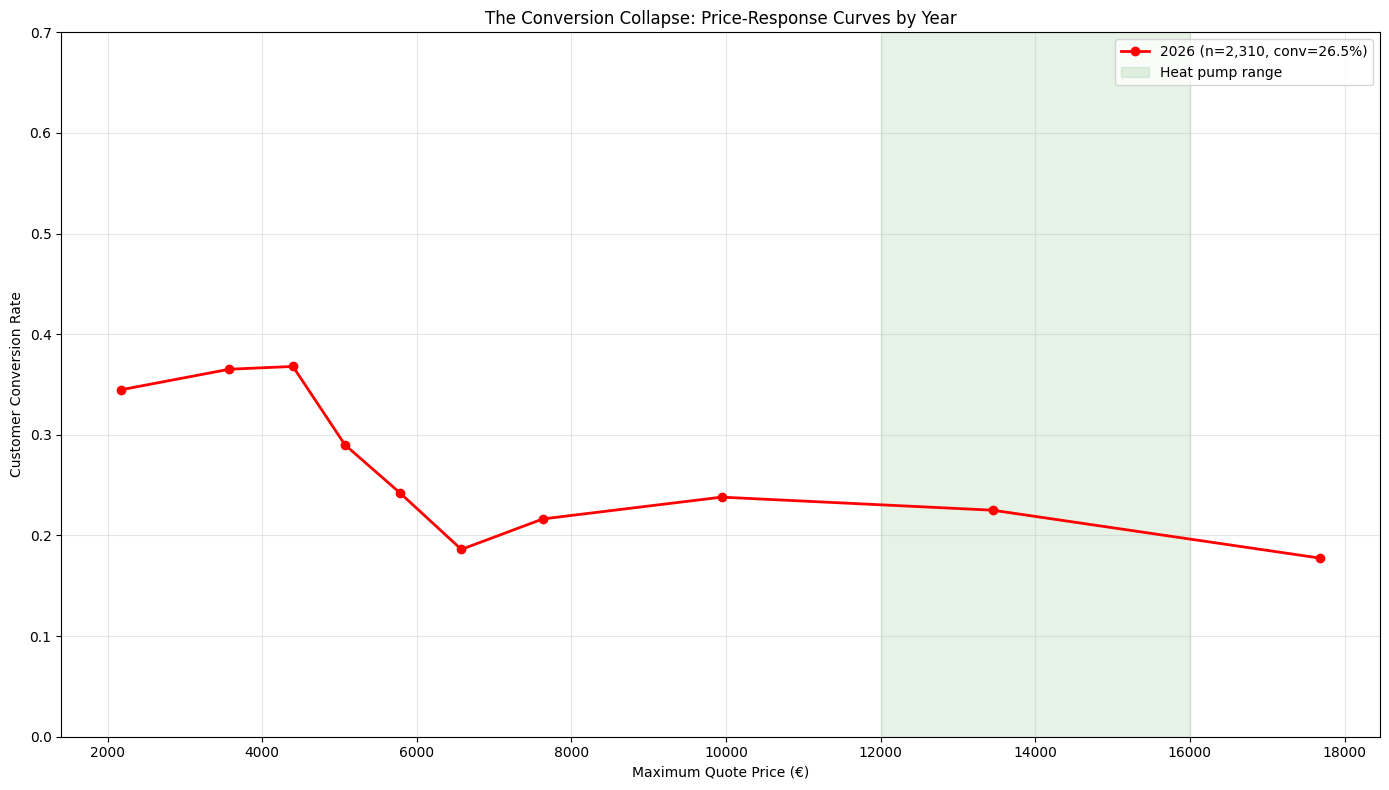


Sweet Spot Analysis Over Time

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126

Sweet spots by year (price points with conversion > avg + 3%):


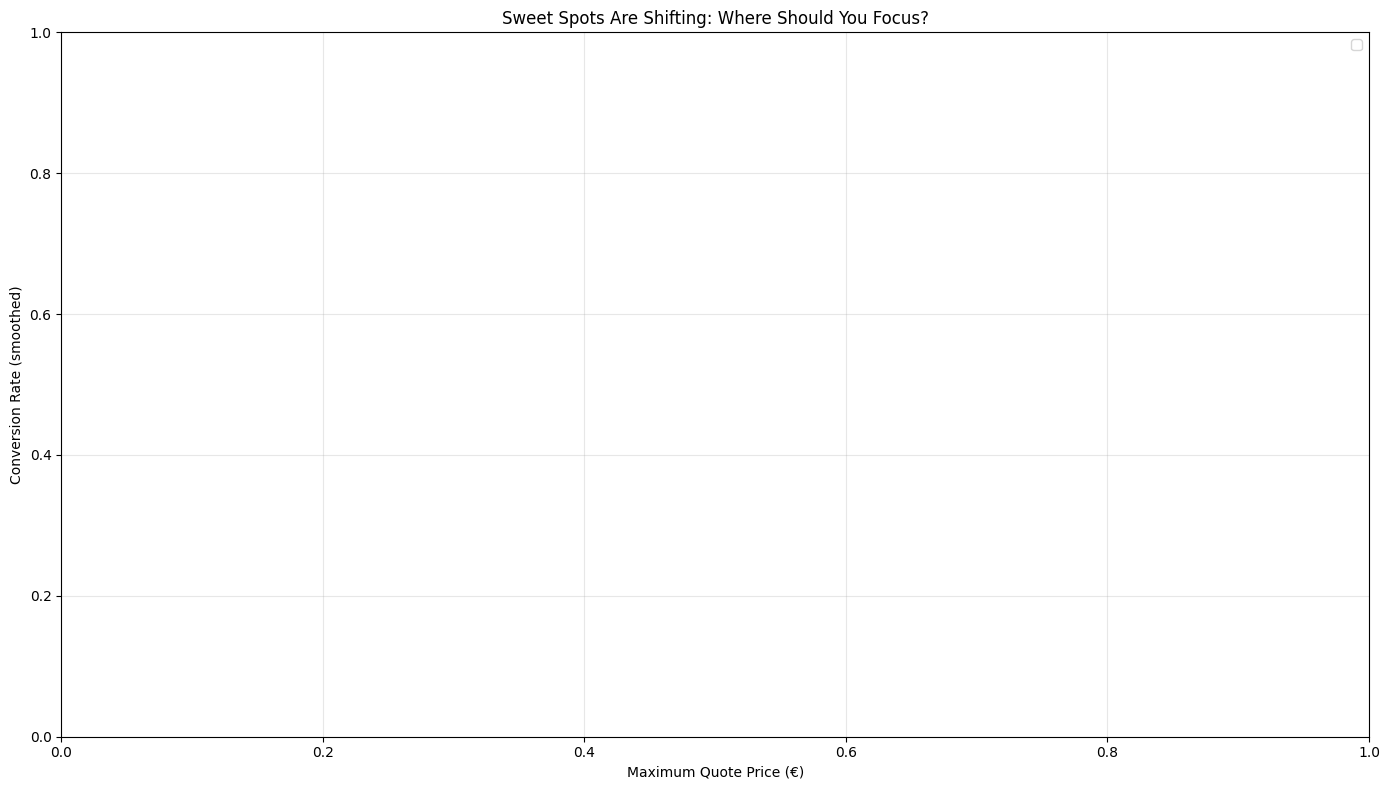


Administrative Uncertainty Effect

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126

Decision time distribution:
count    2310.000000
mean        2.386580
std         6.382556
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        67.000000
Name: decision_days, dtype: float64

Customers with 1-day decision: 2,038 (88.2%)


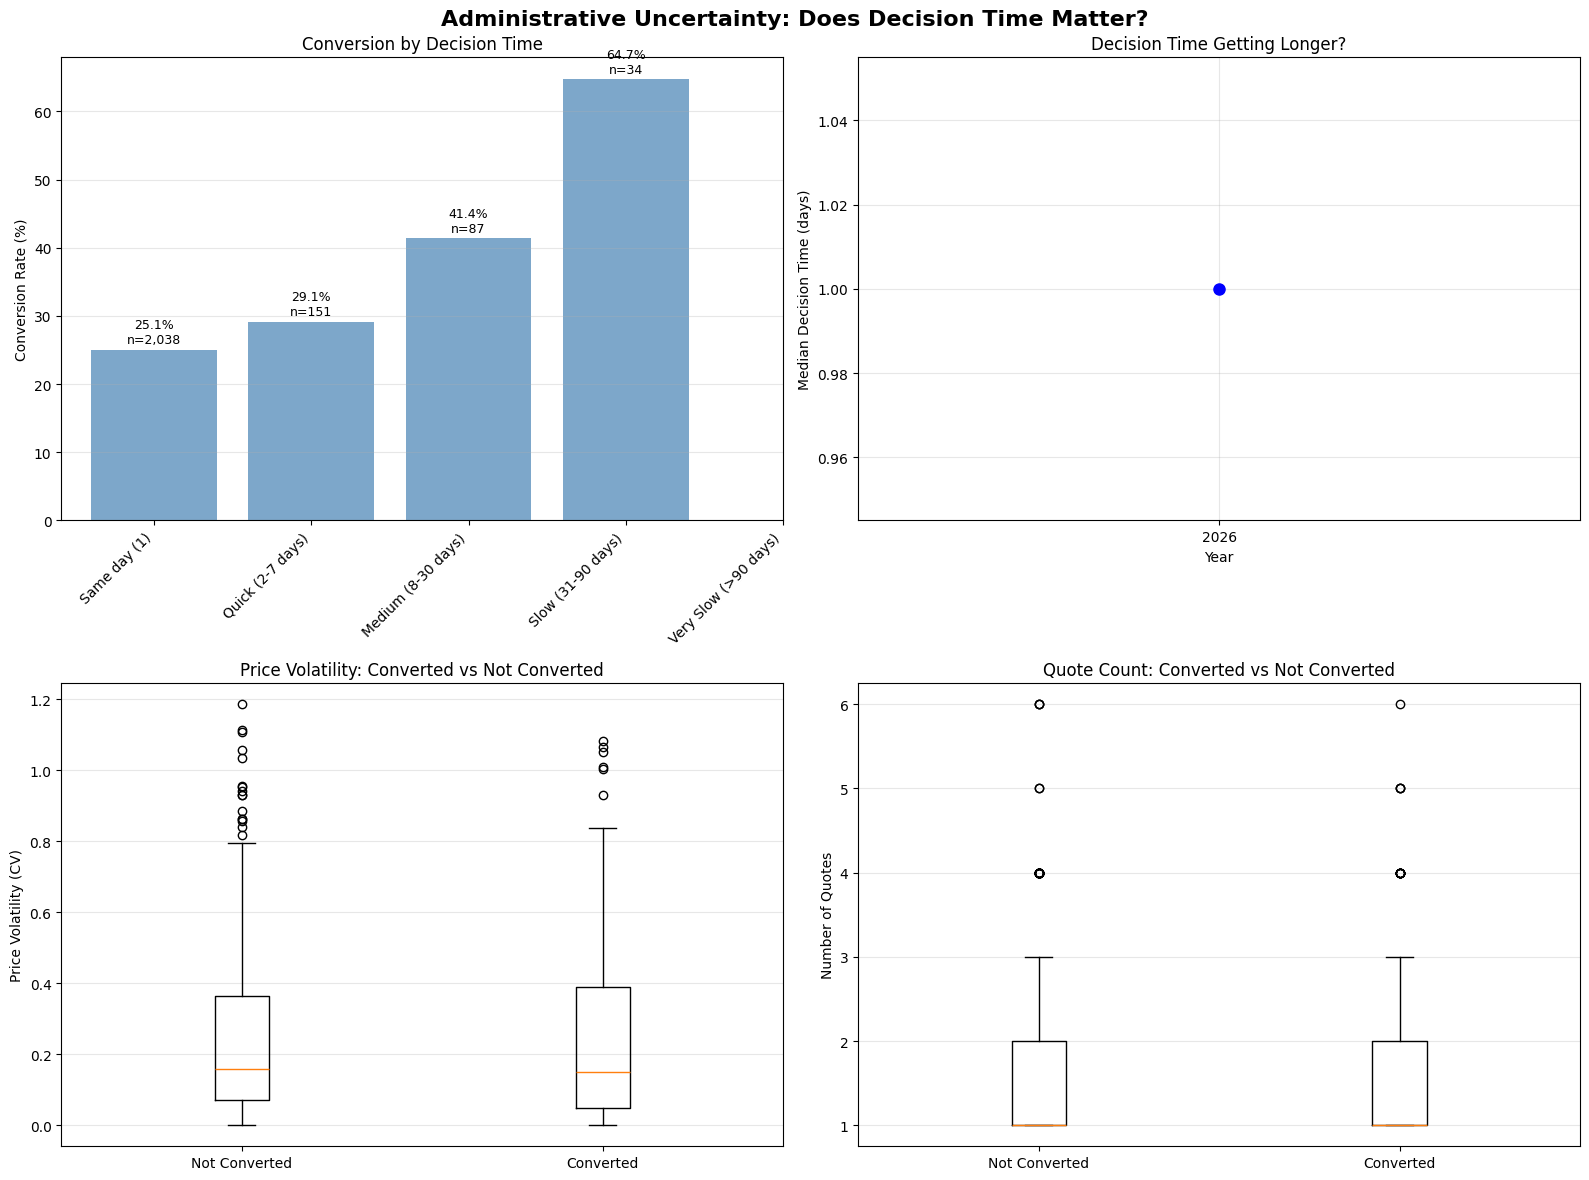


Product Type - Price Conversion Heatmap
Simple pivot table:
price_bin_simple         (1103.269, 3947.814]  (3947.814, 5431.284]  \
main_equipment_category                                               
AC                                  29.126214             32.352941   
Boiler                              41.919192             31.034483   
Heat Pump                                 NaN            100.000000   
Other                               32.484076             25.000000   
Stove                               64.285714             34.883721   

price_bin_simple         (5431.284, 7011.9]  (7011.9, 11942.726]  \
main_equipment_category                                            
AC                                19.512195            19.548872   
Boiler                            28.358209            29.861111   
Heat Pump                          0.000000            28.571429   
Other                             44.444444            23.529412   
Stove                            

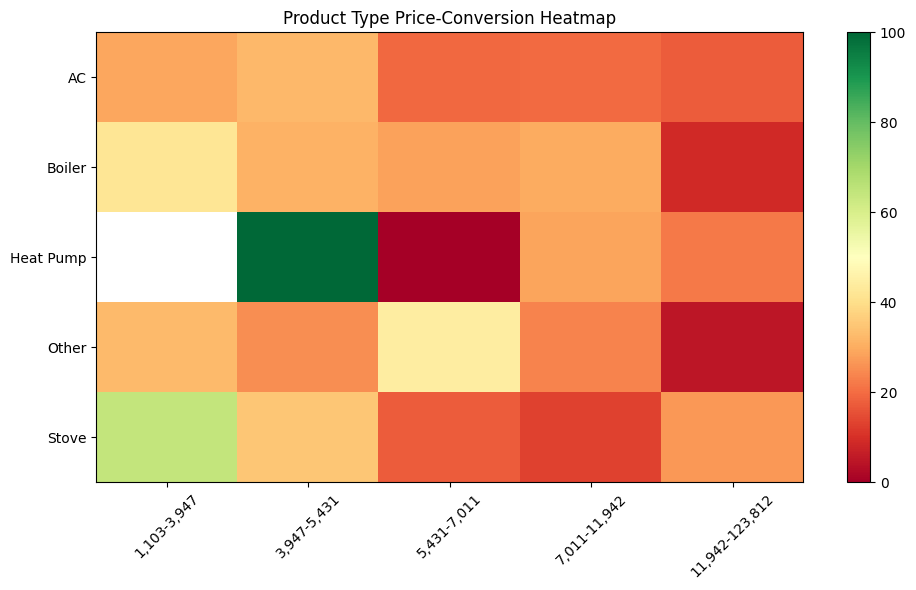


CHECKING MAIN PRODUCT FAMILY
main_product_family
Chaudière                           797
Poêle                               518
Climatisation                       472
Pompe à chaleur                     373
ECS : Chauffe-eau ou adoucisseur    139
Photovoltaïque                       36
Unknown                              16
Autres                               16
Emetteur de chauffage  ou chappe     14
Produit VMC                           8
Appareil hybride                      3
Accessoire de pose                    3
Plomberie Sanitaire                   2
Name: count, dtype: int64

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126


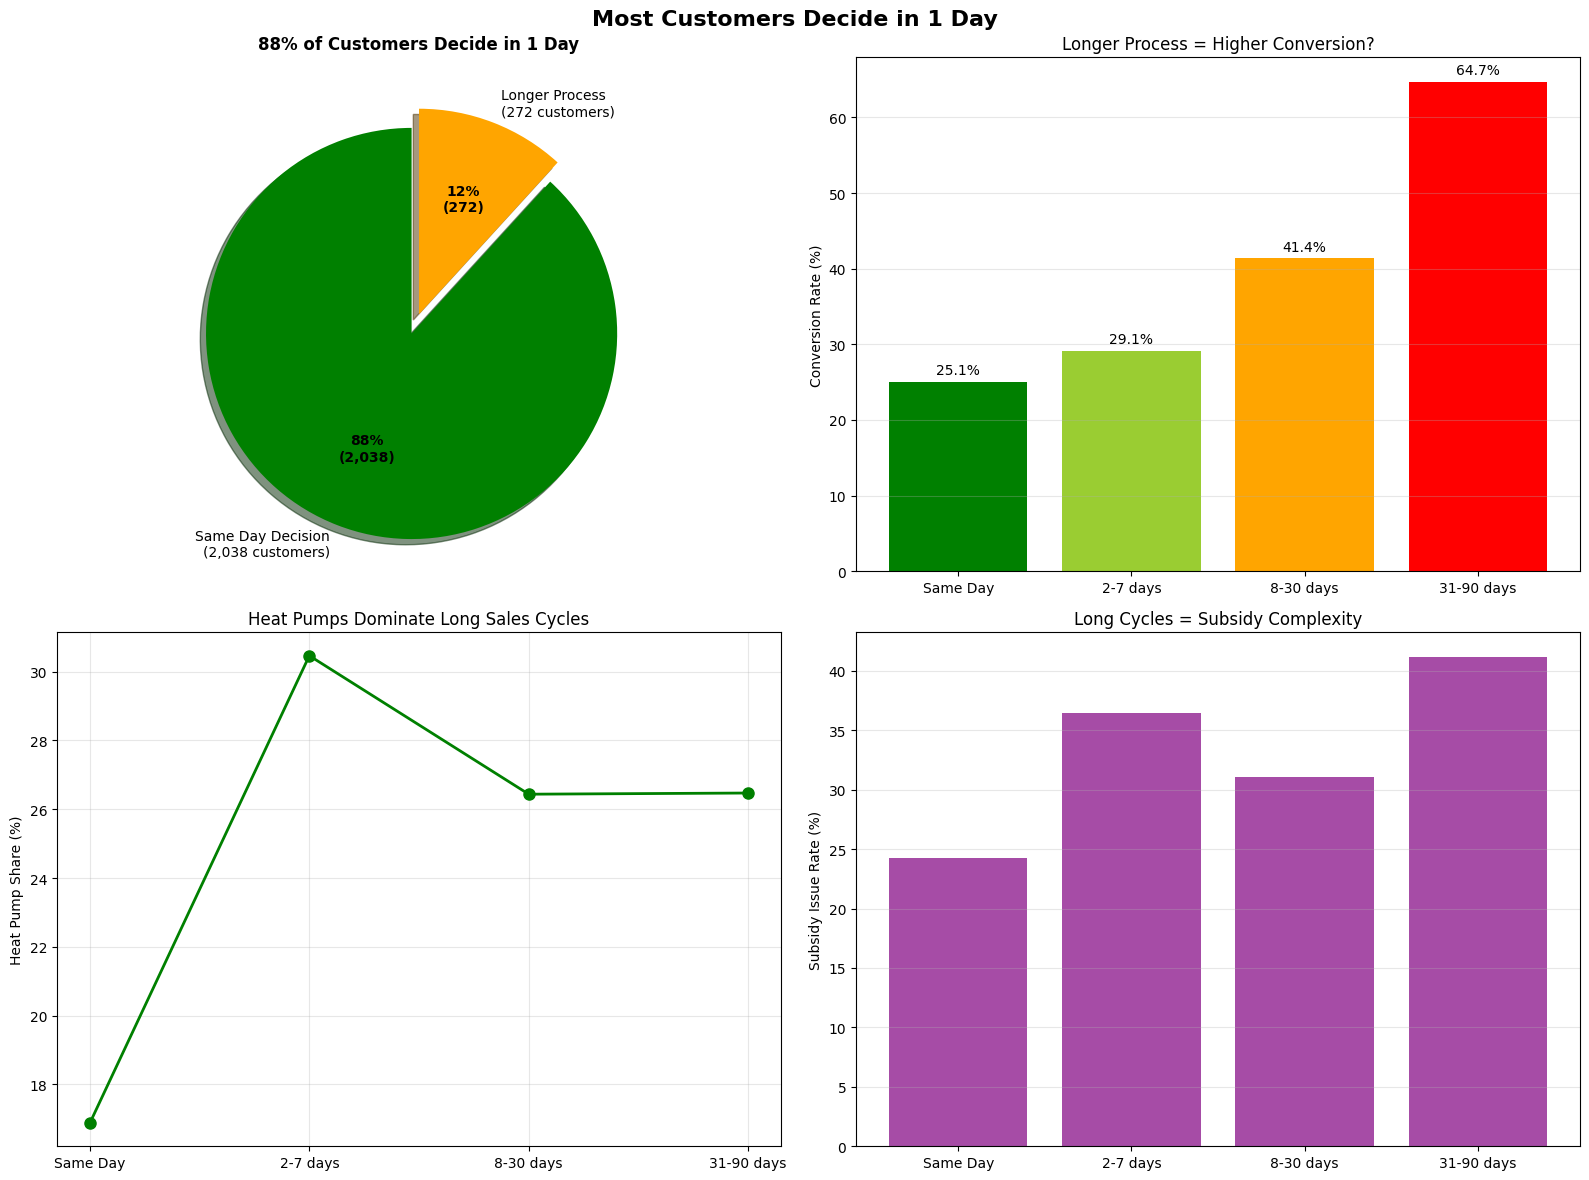


Heat Pump Performance Over Time

Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126

Heat pump customers by year:
        conversion_rate  customer_count  avg_price  subsidy_issue_rate
period                                                                
2026              0.237             422  14897.542               0.775


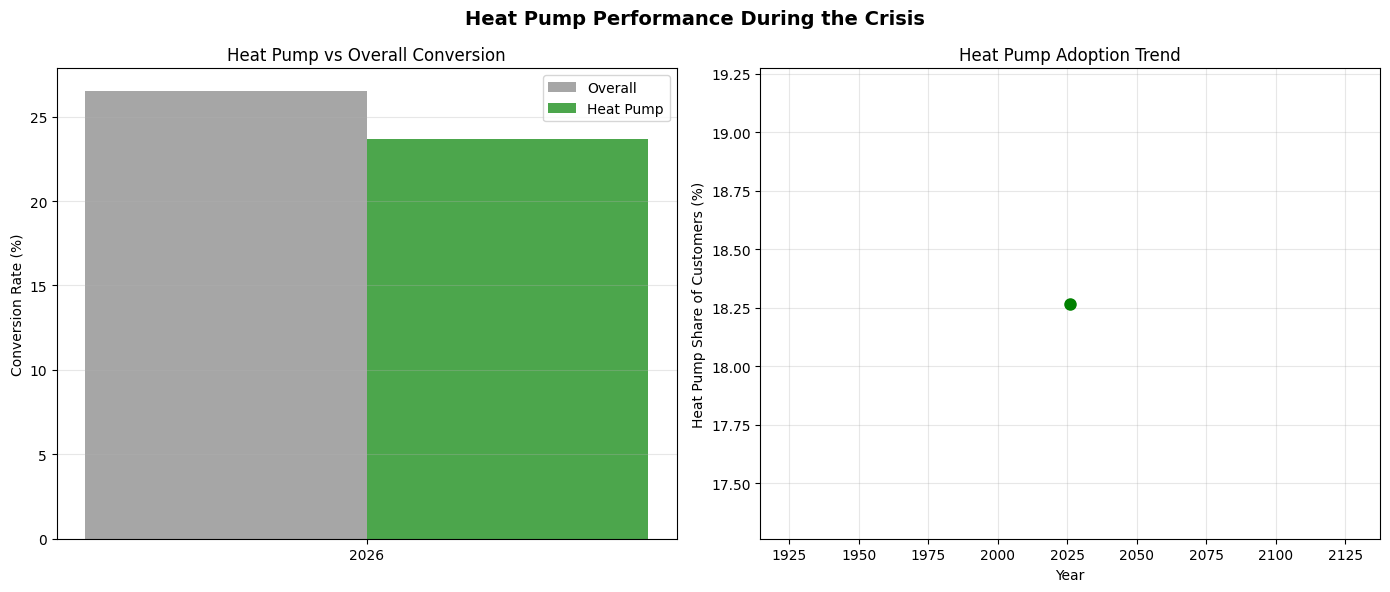


Analyzing 2,310 customers
Price range: €1,327 to €25,676
Median price: €6,126

DYNAMIC INSIGHTS CALCULATED:
Sweet spots: €4.4k (44.2%) and €3.6k (40.3%)
Dead zone: €6.7k-7.0k (14-21%)
Heat pumps: 77% subsidy issues, 23.7% conversion
Price sensitivity: Stove (22.5pts) > Heat Pump (14.9pts) > Boiler (14.7pts) > AC (7.8pts)
Same day decisions: 88%


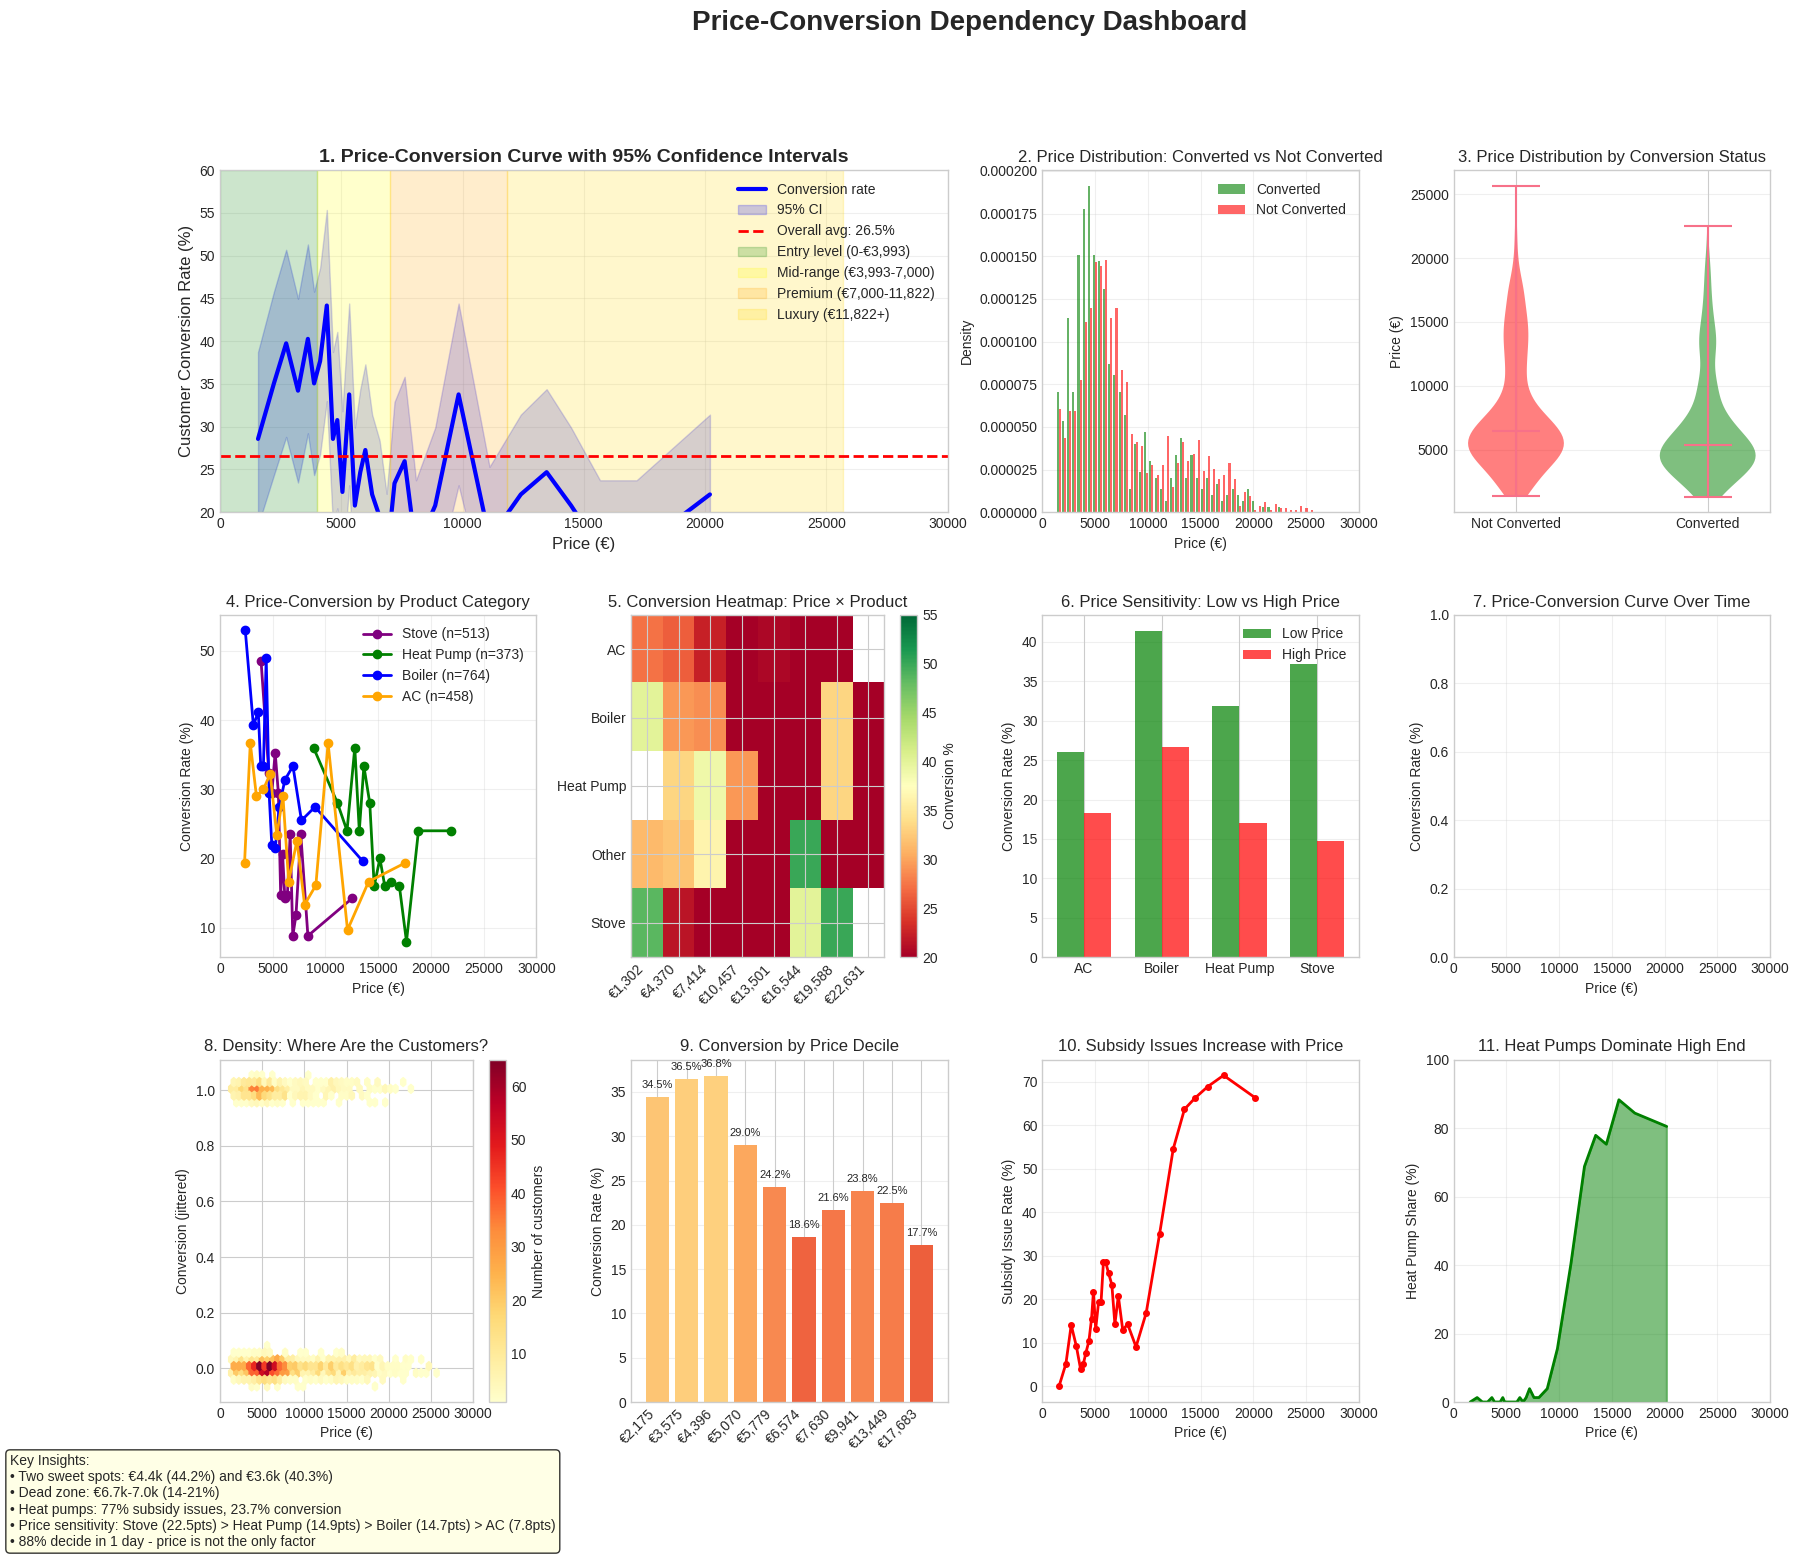

Actual product categories in data: ['AC', 'Boiler', 'Heat Pump', 'Other', 'Stove']


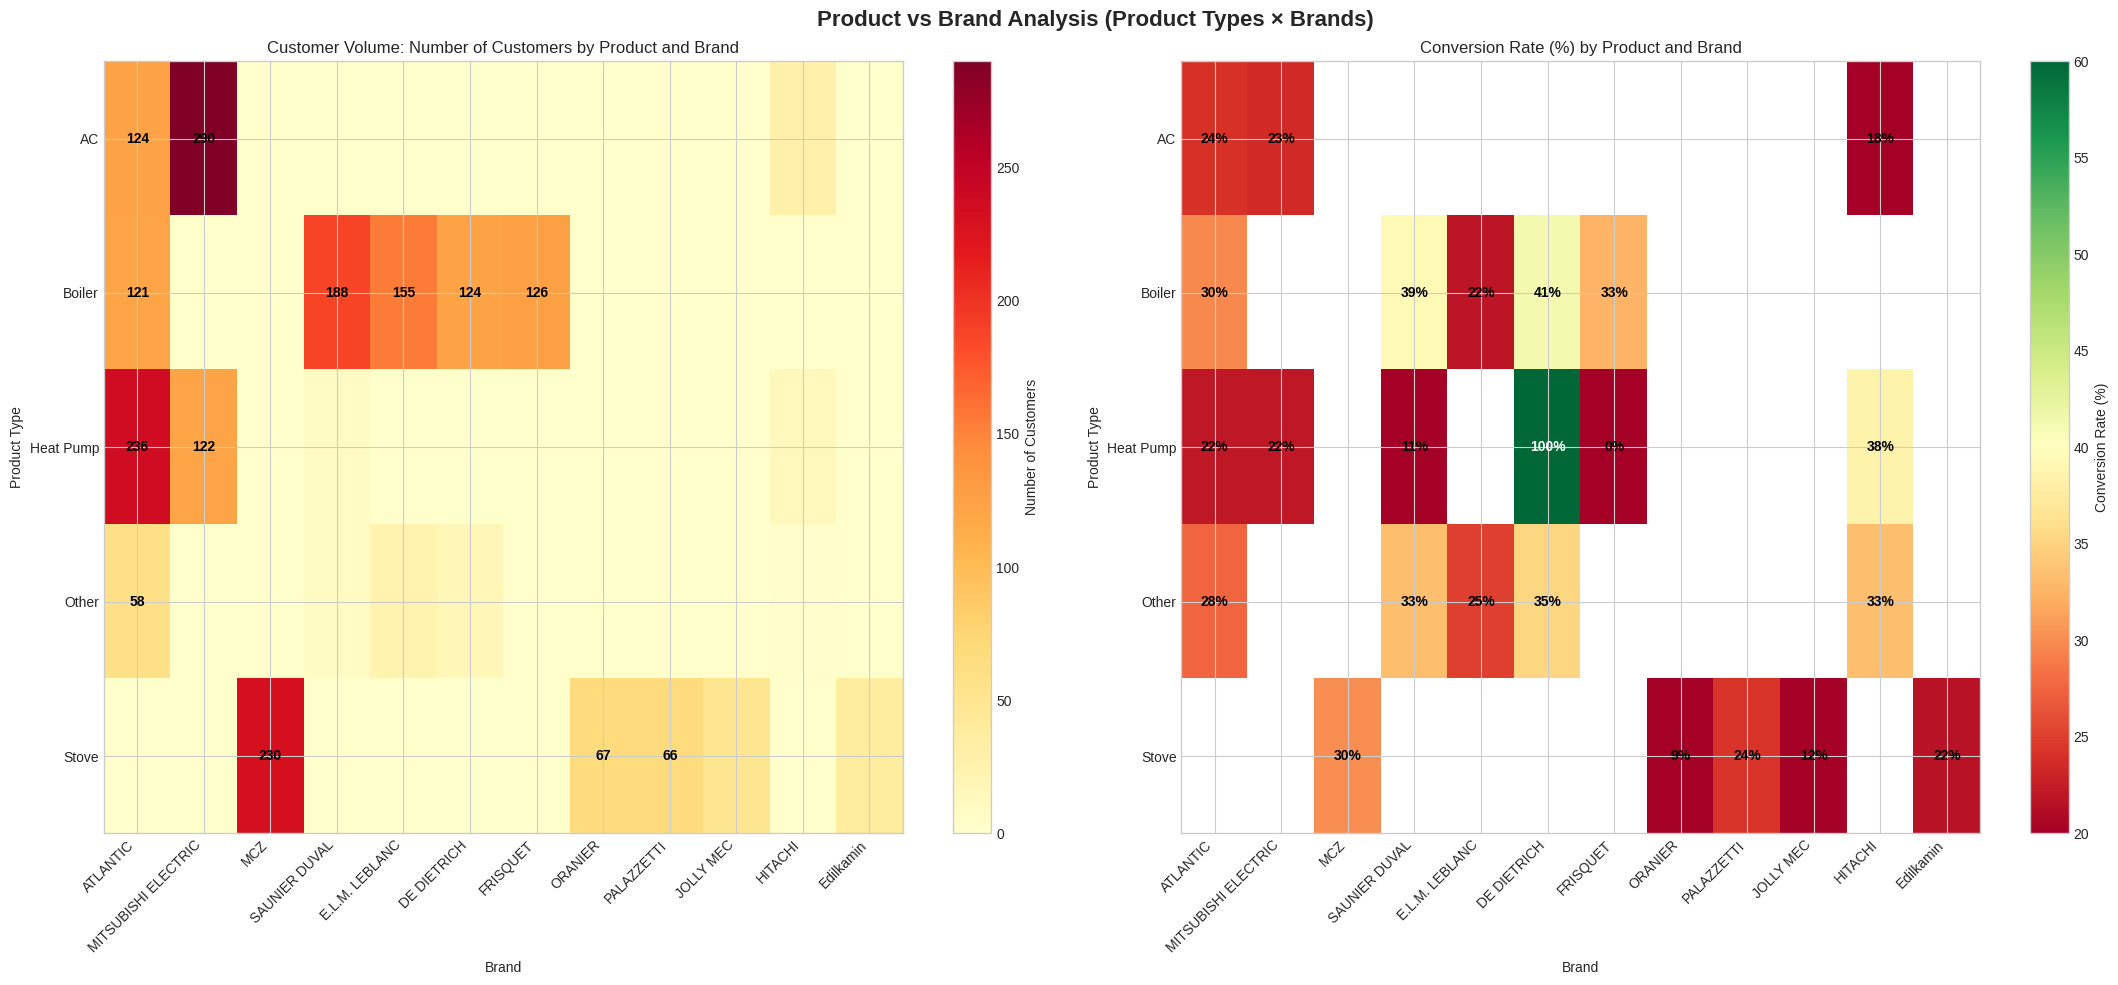


PRODUCT × BRAND ANALYSIS

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_brand               ATLANTIC  MITSUBISHI ELECTRIC  MCZ  SAUNIER DUVAL  E.L.M. LEBLANC  DE DIETRICH  FRISQUET  ORANIER  PALAZZETTI  JOLLY MEC  HITACHI  Edilkamin
main_equipment_category                                                                                                                                              
AC                            124                  290    0              0               0            0         0        0           0          0       28          0
Boiler                        121                    0    0            188             155          124       126        0           0          0        0          0
Heat Pump                     236                  122    0              9               0            1         1        0           0          0       13          0
Other                

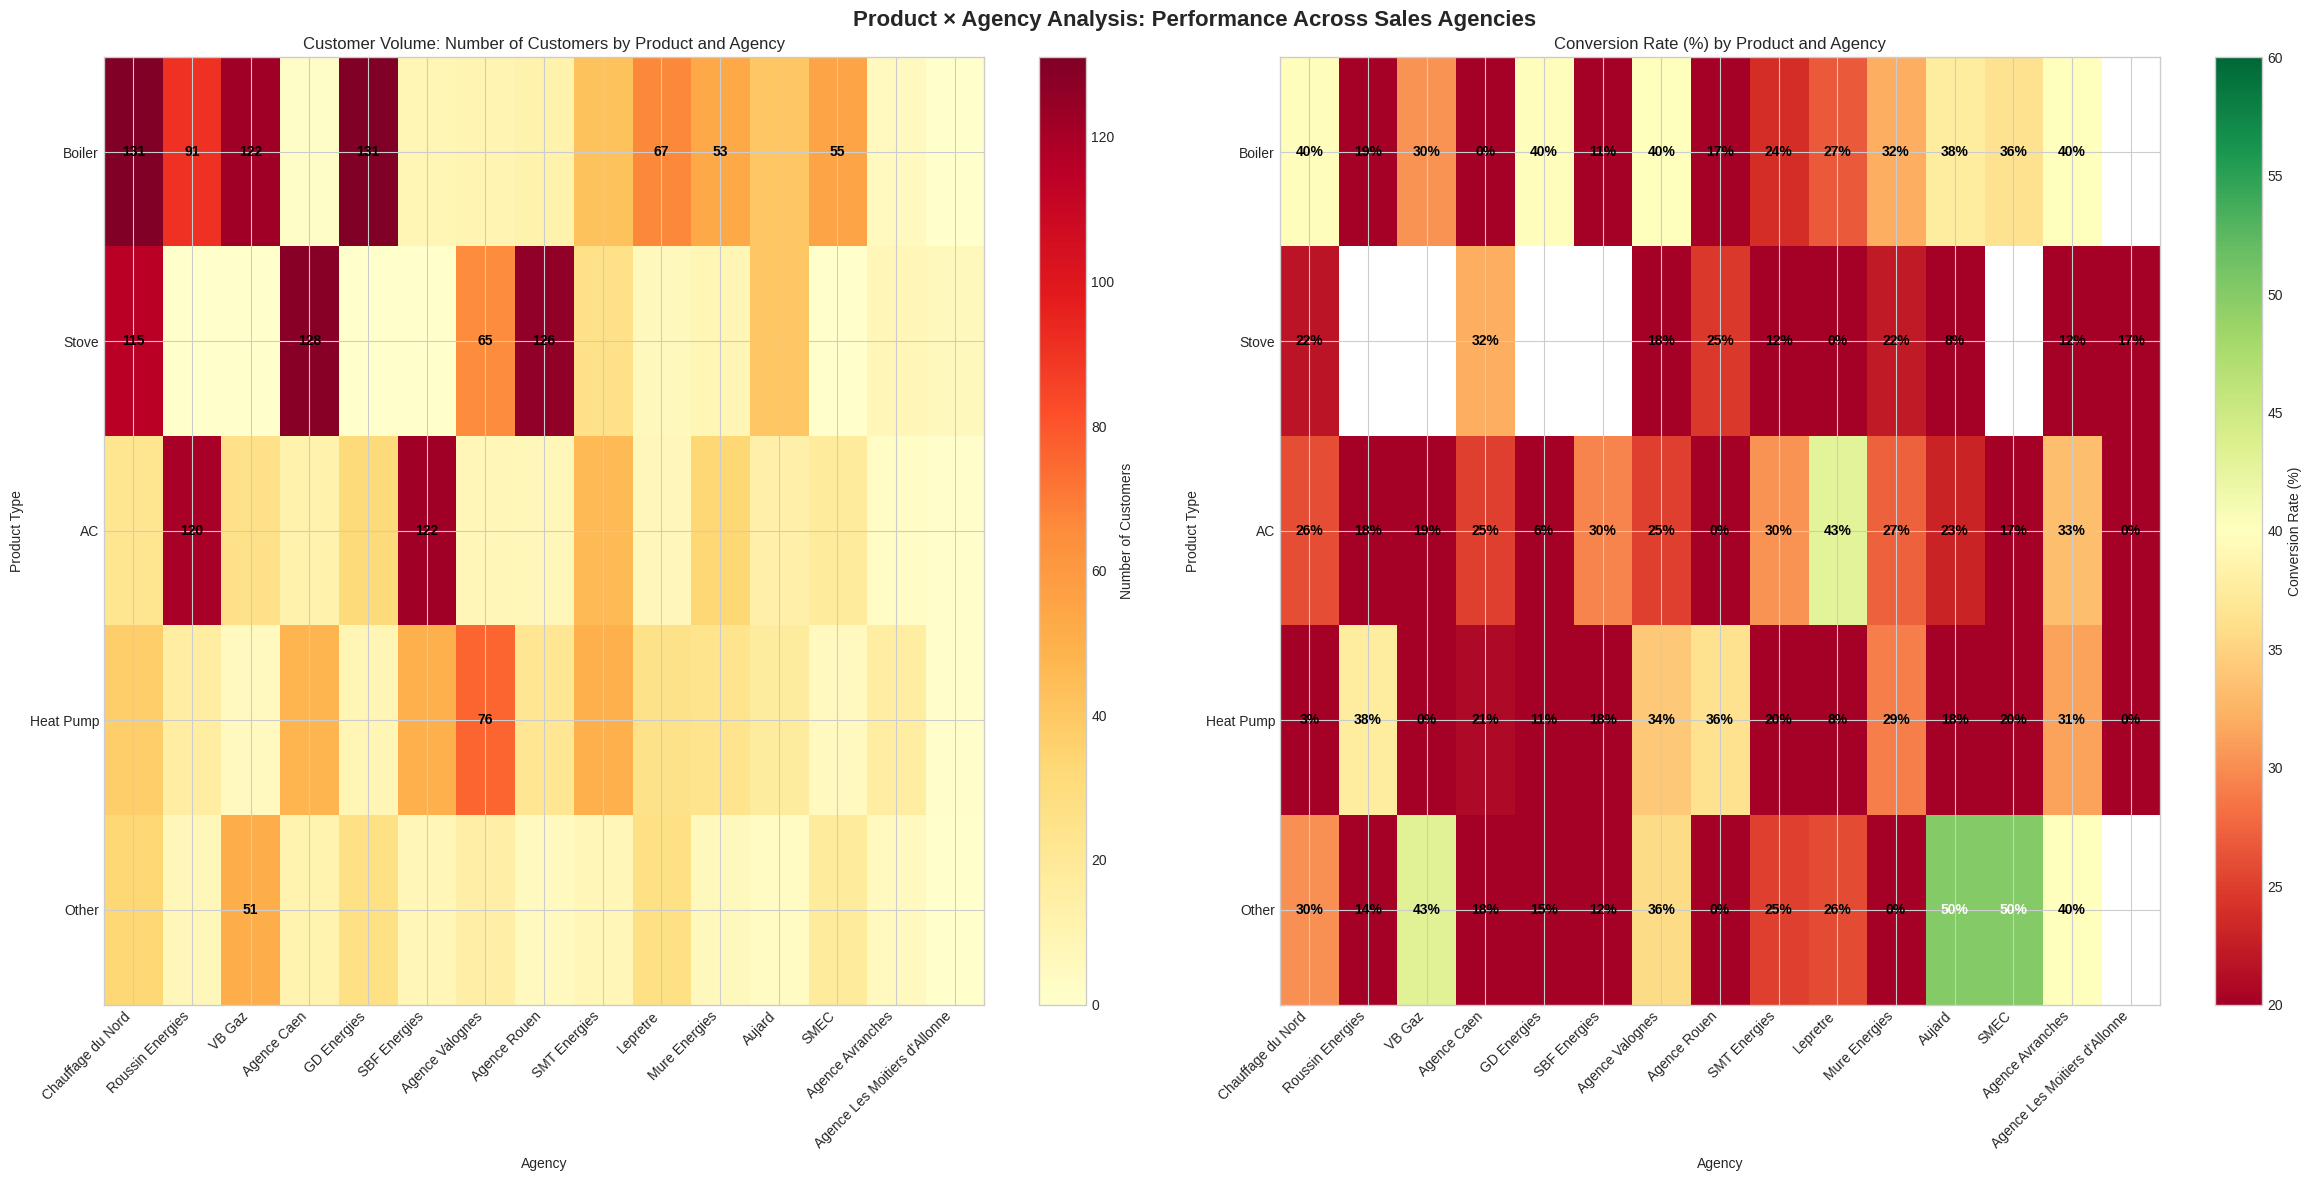


PRODUCT × AGENCY ANALYSIS

📊 CUSTOMER VOLUME BY PRODUCT AND AGENCY:
----------------------------------------------------------------------------------------------------
main_agency              Chauffage du Nord  Roussin Energies  VB Gaz  Agence Caen  GD Energies  SBF Energies  Agence Valognes  Agence Rouen  SMT Energies  Lepretre  Mure Energies  Aujard  SMEC  Agence Avranches  Agence Les Moitiers d'Allonne
main_equipment_category                                                                                                                                                                                                                          
Boiler                                 131                91     122            2          131             9               10            12            42        67             53      40    55                 5                              0
Stove                                  115                 0       0          128            0          

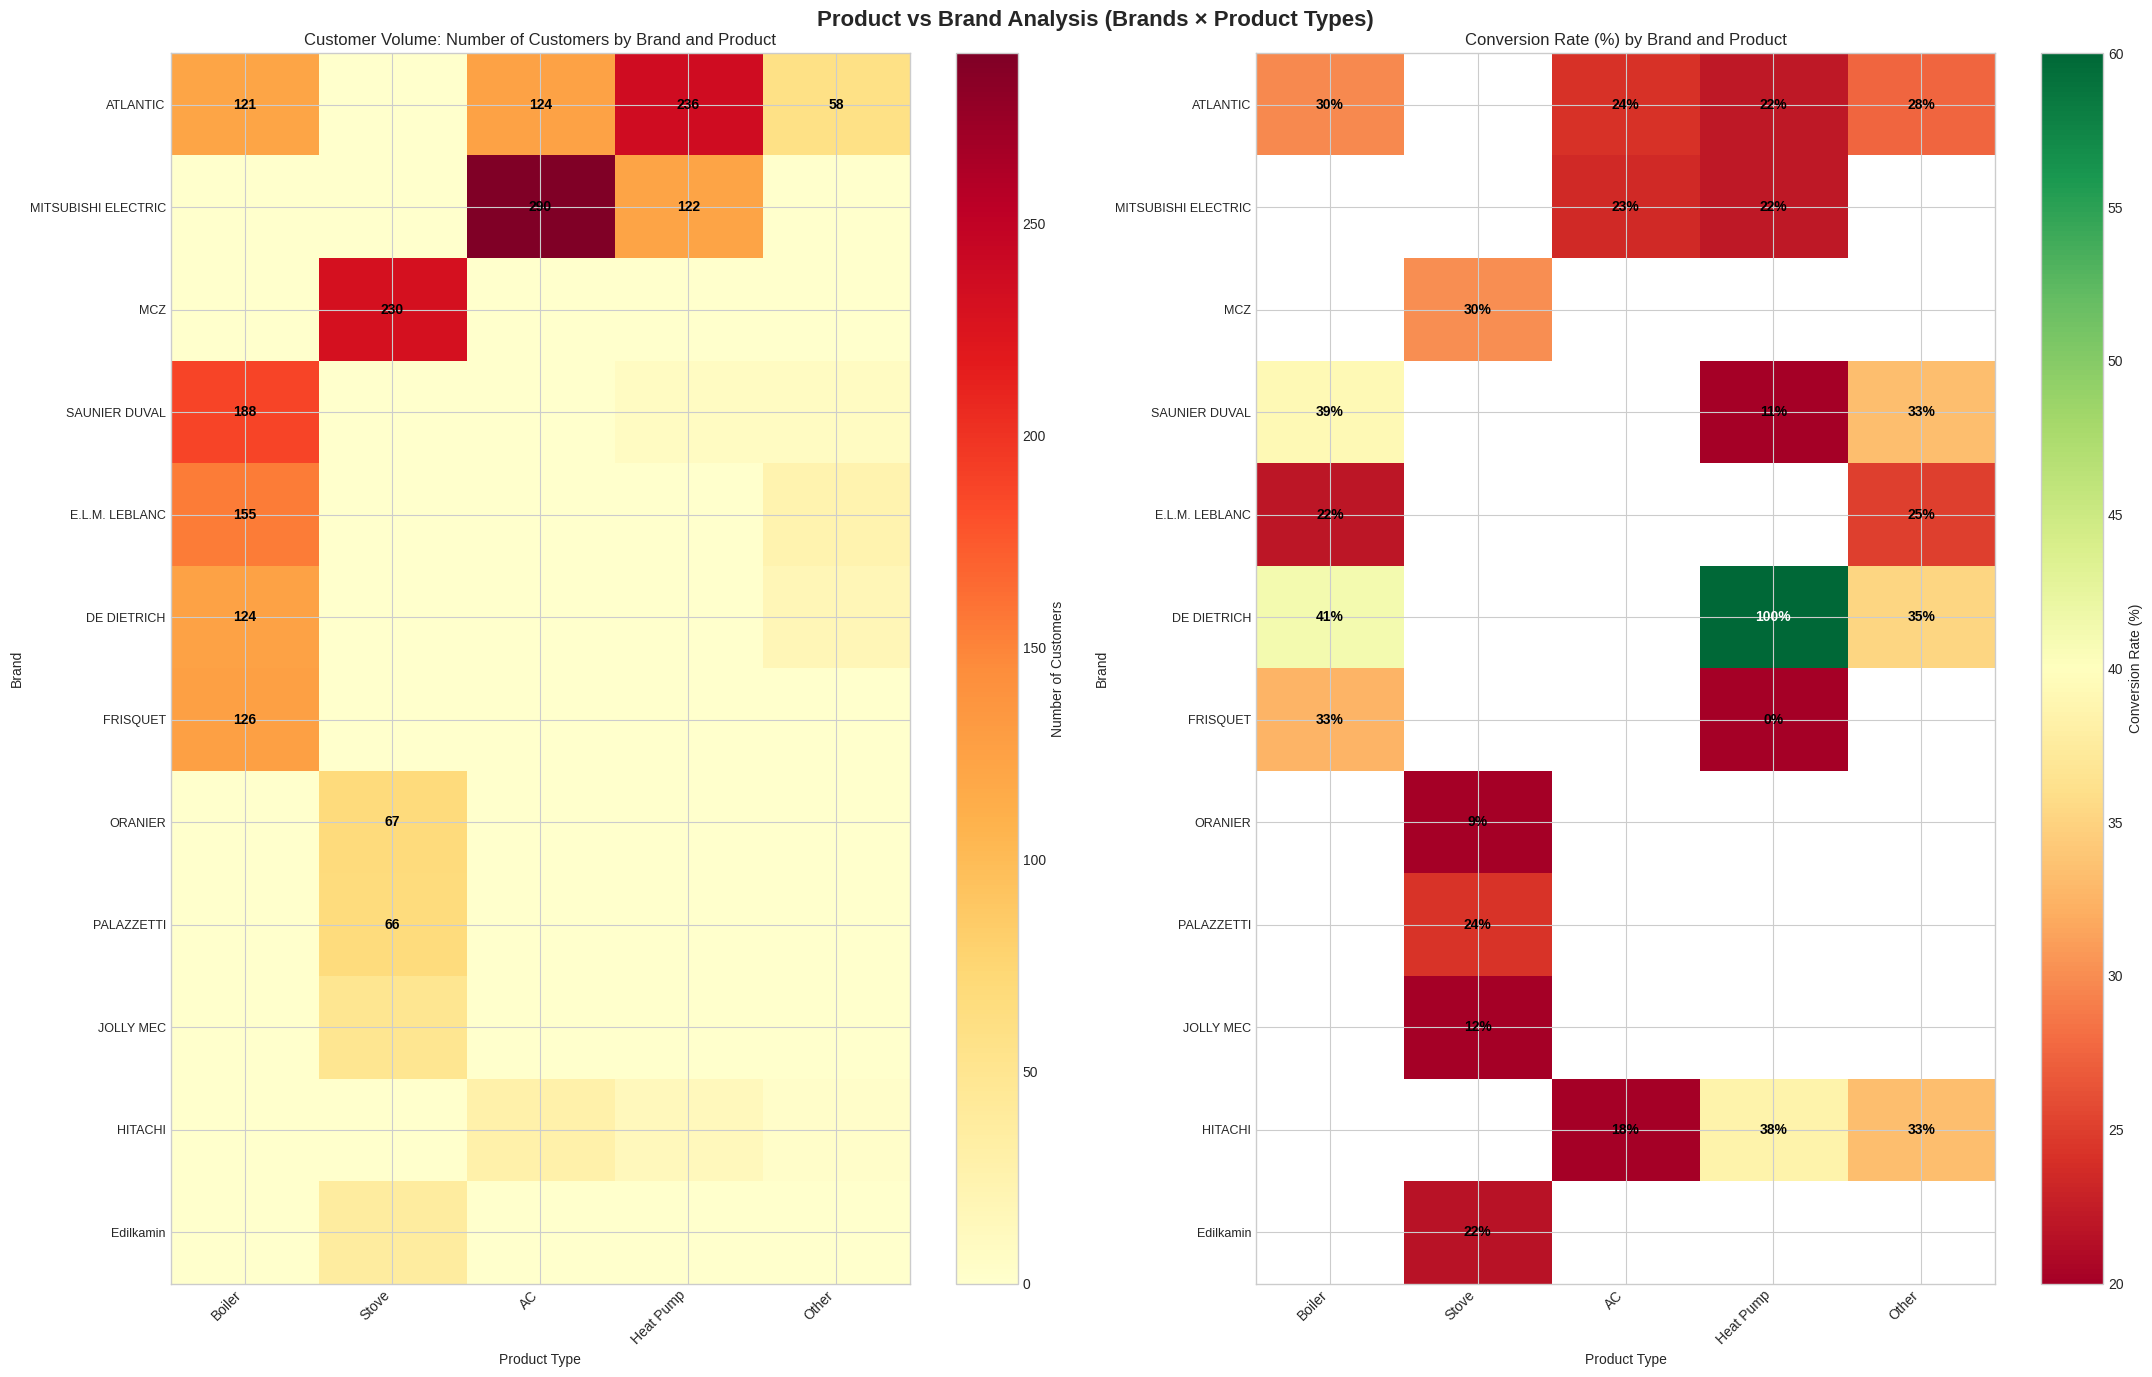


BRAND × PRODUCT ANALYSIS (Swapped Axes)

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_equipment_category  Boiler  Stove   AC  Heat Pump  Other
main_brand                                                   
ATLANTIC                    121      0  124        236     58
MITSUBISHI ELECTRIC           0      0  290        122      0
MCZ                           0    230    0          0      0
SAUNIER DUVAL               188      0    0          9      9
E.L.M. LEBLANC              155      0    0          0     24
DE DIETRICH                 124      0    0          1     17
FRISQUET                    126      0    0          1      0
ORANIER                       0     67    0          0      0
PALAZZETTI                    0     66    0          0      0
JOLLY MEC                     0     49    0          0      0
HITACHI                       0      0   28         13      3
Edilkamin                     

(main_equipment_category  Boiler  Stove   AC  Heat Pump  Other
 main_brand                                                   
 ATLANTIC                    121      0  124        236     58
 MITSUBISHI ELECTRIC           0      0  290        122      0
 MCZ                           0    230    0          0      0
 SAUNIER DUVAL               188      0    0          9      9
 E.L.M. LEBLANC              155      0    0          0     24
 DE DIETRICH                 124      0    0          1     17
 FRISQUET                    126      0    0          1      0
 ORANIER                       0     67    0          0      0
 PALAZZETTI                    0     66    0          0      0
 JOLLY MEC                     0     49    0          0      0
 HITACHI                       0      0   28         13      3
 Edilkamin                     0     37    0          0      0,
 main_equipment_category     Boiler      Stove         AC   Heat Pump  \
 main_brand                                 

In [6]:
conv_no_issue, conv_with_issue = report_customer_conversion_by_subsidy_issue_status(customers)
report_customer_metrics_by_subsidy_issue_status(customers)
visualize_conversion_by_subsidy_issues(customers, conv_no_issue, conv_with_issue)
visualize_policy_suspension_impact(customers, price_var='max_out_of_pocket')

top_products, no_issue_pct, issue_pct = report_customer_subsidy_issues_by_product(customers)
visualize_customer_subsidy_issues_by_product(customers, top_products, no_issue_pct, issue_pct)

visualize_conversion_by_price_sweet_spots(customers, price_var='max_out_of_pocket')
visualize_conversion_by_price_sweet_spots_variant(customers, price_var='max_out_of_pocket')
report_product_conversion_by_price_quartile(customers)
visualize_conversion_by_equipment_category_price(customers, price_var='max_out_of_pocket')
visualise_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
show_two_panel_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
visualize_conversion_by_equipment_type_brand_price(customers, price_var='max_out_of_pocket')

visualize_conversion_by_season(customers, price_var='max_out_of_pocket')
visualize_regional_seasonality(customers, price_var='max_out_of_pocket')

visualize_conversion_by_year(customers, price_var='max_out_of_pocket')
report_best_and_worst_months(customers, price_var='max_out_of_pocket')
show_conversion_by_price_over_time(customers, price_var='max_out_of_pocket')
overlay_all_years_on_one_plot(customers, price_var='max_out_of_pocket')
visualize_conversion_by_prices_sweet_spot_shift(customers, price_var='max_out_of_pocket')
visualize_decision_times(customers, price_var='max_out_of_pocket')
show_product_type_price_conversion_heatmap(customers, price_var='max_out_of_pocket')
show_decision_time_dashboard(customers, price_var='max_out_of_pocket')

visualise_heat_pump_performance(customers, price_var='max_out_of_pocket')

show_conversion_by_price_dashboard(customers, price_var='max_out_of_pocket')

show_product_type_by_brand_heatmap(customers)
show_product_type_by_agency_heatmap(customers)
show_brand_by_product_type_heatmap(customers)

In [9]:
import ipynbname
import subprocess
import os
import sys

def export_notebook_to_pdf(overwrite=True, verbose=True):
    """
    Export current notebook to PDF with overwrite control
    
    Args:
        overwrite (bool): If True, overwrite existing PDF file
        verbose (bool): If True, print progress messages
    
    Returns:
        bool: True if successful, False otherwise
    """
    try:
        # Get notebook path
        notebook_path = ipynbname.path()
        notebook_path_str = str(notebook_path)
        pdf_path = notebook_path_str.replace('.ipynb', '.pdf')
        
        if verbose:
            print(f"📓 Notebook: {notebook_path.name}")
            print(f"📄 PDF path: {pdf_path}")
        
        # Check if PDF exists
        if os.path.exists(pdf_path):
            if overwrite:
                if verbose:
                    print(f"🗑️ Removing existing PDF: {pdf_path}")
                os.remove(pdf_path)
            else:
                if verbose:
                    print(f"⚠️ PDF already exists and overwrite=False")
                return False
        
        # Convert to PDF
        if verbose:
            print("🔄 Converting to PDF...")
        
        result = subprocess.run([
            'jupyter', 'nbconvert', '--to', 'pdf',
            '--no-prompt',  # Suppress input prompts
            notebook_path_str
        ], capture_output=True, text=True)
        
        if result.returncode == 0:
            if verbose:
                print(f"✅ PDF saved: {pdf_path}")
            return True
        else:
            if verbose:
                print(f"❌ Conversion failed:")
                print(result.stderr)
            return False
            
    except Exception as e:
        if verbose:
            print(f"❌ Error: {e}")
        return False

# Use the function
if __name__ == "__main__":
    # Overwrite existing PDF
    export_notebook_to_pdf(overwrite=True)
    
    # Or create new version without overwriting
    # export_notebook_to_pdf(overwrite=False)export_full_notebook_to_pdf()

❌ Error: Can't identify the notebook path.


In [13]:
# Just hardcode your notebook name
notebook_name = "your_notebook_name.ipynb"  # Change this!

import subprocess
import os

pdf_path = notebook_name.replace('.ipynb', '.pdf')
if os.path.exists(pdf_path):
    os.remove(pdf_path)
    
subprocess.run(['jupyter', 'nbconvert', '--to', 'pdf', '--no-prompt', "_eda_price_2026_Q1.ipynb"])

[NbConvertApp] Converting notebook _eda_price_2026_Q1.ipynb to pdf
[NbConvertApp] Support files will be in _eda_price_2026_Q1_files/
[NbConvertApp] Making directory ./_eda_price_2026_Q1_files
[NbConvertApp] Writing 95072 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 2354027 bytes to _eda_price_2026_Q1.pdf


CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'pdf', '--no-prompt', '_eda_price_2026_Q1.ipynb'], returncode=0)